## Reddit 연결 진단 가이드 (먼저 실행)

- 이 섹션은 Reddit 수집 셀 실행 전, 환경 변수/네트워크/PRAW 최소 호출을 빠르게 점검합니다.
- 순서:
  1) 아래 "Reddit 연결 진단 (코드)" 셀 실행 → Summary 값 확인
  2) env_ok=false면 .env 키 설정/재로드
  3) http_public_ok=false면 네트워크/프록시 확인
  4) praw_minimal_query_ok=false면 Reddit 앱/자격 증명 확인
- 정상이라면 본문 수집 셀을 실행하세요. 느리면 댓글 확장(replace_more) 부분을 잠시 비활성화해 속도를 점검하세요.


In [2]:
# Notebook init (no-op)
pass

# 초보 요리 고충 탐색 데이터 수집/분석 노트북
본 노트북은 LG 스마트 키친 전략 문서(냉장고를 부탁해)를 뒷받침하기 위해, Reddit/Stack Exchange/YouTube/Naver 등 복수 소스의 API 데이터를 수집하여 초보 요리인의 ‘고충(Pain Points)’을 규명하는 파이프라인을 제공합니다.
- 각 섹션과 셀마다 주석과 설명을 자세히 달았습니다.
- 네트워크/키 제한이 있을 수 있으니 .env 설정과 섹션별 guard 코드를 확인하세요.
- 오프라인에서도 부분 실행이 가능하도록 캐시/옵션 스위치를 제공합니다.

## 1) Install and Import Libraries
필요한 패키지를 설치/임포트합니다. 사내/교육망 환경 또는 Windows PowerShell에서의 설치 이슈를 고려하여, 실패 시 메시지를 안내합니다.
- requests, requests_cache, backoff: HTTP 호출, 캐시, 재시도
- praw: Reddit API 클라이언트
- googleapiclient (YouTube Data API)
- langdetect: 언어 감지
- pandas, numpy: 데이터프레임/수치
- matplotlib, seaborn: 시각화
- scikit-learn: 전처리/TF-IDF/LDA
- nltk (VADER): 감성분석
- yake: 키프레이즈 추출
- pytrends: Google Trends (선택)
- python-dotenv: 환경변수 로드

In [3]:
# NOTE: 이 셀은 필요한 패키지를 설치하고 임포트합니다.
# - Windows PowerShell 환경에서 pip가 python -m pip로 동작할 수 있어 둘 다 시도합니다.
# - 설치는 최초 1회만 필요. 이후에는 주석 처리해도 됩니다.

import sys, subprocess, importlib

required = [
    'requests', 'requests_cache', 'backoff', 'praw',
    'google-api-python-client', 'langdetect', 'pandas', 'numpy',
    'matplotlib', 'seaborn', 'scikit-learn', 'nltk', 'yake',
    'pytrends', 'python-dotenv', 'deep-translator'
]

# 설치 헬퍼

def ensure(pkg):
    try:
        if pkg == 'google-api-python-client':
            importlib.import_module('googleapiclient.discovery')
        else:
            importlib.import_module(pkg.split('==')[0])
        return
    except Exception:
        pass
    print(f"Installing {pkg} ...")
    cmd = [sys.executable, '-m', 'pip', 'install', pkg]
    try:
        subprocess.check_call(cmd)
    except Exception:
        # 최후 수단: pip 직접 호출
        subprocess.check_call(['pip', 'install', pkg])

for p in required:
    ensure(p)

# 임포트
import os, json, re, time, math, hashlib, datetime as dt
from typing import List, Dict, Any, Optional

import requests
import requests_cache
import backoff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42  # 재현성

# NLP/ML
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import yake

# Optional
try:
    from pytrends.request import TrendReq
    HAS_TRENDS = True
except Exception:
    HAS_TRENDS = False

# Reddit & YouTube
import praw
from googleapiclient.discovery import build

# Translation (optional)
from deep_translator import GoogleTranslator

print("Setup complete. Versions:")
print("pandas", pd.__version__)
print("sklearn", __import__('sklearn').__version__)


Installing scikit-learn ...
Installing python-dotenv ...
Installing python-dotenv ...
Installing deep-translator ...
Installing deep-translator ...
Setup complete. Versions:
pandas 2.2.2
sklearn 1.7.1
Setup complete. Versions:
pandas 2.2.2
sklearn 1.7.1


## 2) Configure API Keys and Query Parameters
.env 파일에서 API 키를 로드하고, 수집 파라미터(기간/한도/키워드)를 설정합니다.
- Reddit: REDDIT_CLIENT_ID, REDDIT_CLIENT_SECRET, REDDIT_USER_AGENT
- YouTube: YOUTUBE_API_KEY
- Naver: NAVER_CLIENT_ID, NAVER_CLIENT_SECRET
- Twitter(X, 선택): TWITTER_BEARER_TOKEN
기간은 최근 n일로 설정하며, 키가 없으면 해당 섹션은 건너뜁니다.

In [4]:
# .env 로드 및 파라미터 설정 (견고한 경로 탐색 포함)
from pathlib import Path
from dotenv import load_dotenv, find_dotenv

# 현재 작업 디렉토리 기준으로 상위 폴더까지 .env 탐색
env_path = find_dotenv(usecwd=True)
loaded = False
if env_path:
    loaded = load_dotenv(env_path)

# 폴백: 워크스페이스 루트 추정 경로도 시도
if not loaded:
    candidate = Path.cwd().parents[2] / '.env' if len(Path.cwd().parents) >= 3 else None
    if candidate and candidate.exists():
        loaded = load_dotenv(candidate)
        env_path = str(candidate)

print({'env_loaded': loaded, 'env_path': env_path or None, 'cwd': str(Path.cwd())})

REDDIT_CLIENT_ID = os.getenv('REDDIT_CLIENT_ID')
REDDIT_CLIENT_SECRET = os.getenv('REDDIT_CLIENT_SECRET')
REDDIT_USER_AGENT = os.getenv('REDDIT_USER_AGENT', 'lgdx-cooking-painpoints/0.1')
YOUTUBE_API_KEY = os.getenv('YOUTUBE_API_KEY')
NAVER_CLIENT_ID = os.getenv('NAVER_CLIENT_ID')
NAVER_CLIENT_SECRET = os.getenv('NAVER_CLIENT_SECRET')
TWITTER_BEARER_TOKEN = os.getenv('TWITTER_BEARER_TOKEN')

# 수집 기간/한도 설정
DAYS = 60  # 최근 60일
SINCE = int((dt.datetime.utcnow() - dt.timedelta(days=DAYS)).timestamp())
UNTIL = int(dt.datetime.utcnow().timestamp())
MAX_PER_SOURCE = 400  # 각 소스별 상한

# 다국어 키워드 (EN/KR)
KEYWORDS = [
    'beginner', 'new cook', 'struggle', 'failed', 'fail dish', 'meal kit', 'time', 'waste', 'fear', 'menu',
    'overwhelmed', 'burnt', 'undercooked', 'confused', 'shopping', 'prep', 'cleanup',
    '요리 초보', '초보', '실패', '망함', '시간 부족', '음식물 쓰레기', '메뉴 고민', '두려움', '장보기', '손질', '설거지'
]

print({
    'reddit_keys': bool(REDDIT_CLIENT_ID and REDDIT_CLIENT_SECRET),
    'youtube_key': bool(YOUTUBE_API_KEY),
    'naver_keys': bool(NAVER_CLIENT_ID and NAVER_CLIENT_SECRET),
    'twitter_key': bool(TWITTER_BEARER_TOKEN),
    'date_range_utc': (SINCE, UNTIL)
})

{'env_loaded': True, 'env_path': 'c:\\Users\\lgdx\\LG_DX_School\\.env', 'cwd': 'c:\\Users\\lgdx\\LG_DX_School\\03.CX_Group4\\03.oven\\notebooks'}
{'reddit_keys': True, 'youtube_key': True, 'naver_keys': False, 'twitter_key': False, 'date_range_utc': (1752193600, 1757377600)}


C:\Users\lgdx\AppData\Local\Temp\ipykernel_18144\4273207738.py:30: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  SINCE = int((dt.datetime.utcnow() - dt.timedelta(days=DAYS)).timestamp())
C:\Users\lgdx\AppData\Local\Temp\ipykernel_18144\4273207738.py:31: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  UNTIL = int(dt.datetime.utcnow().timestamp())


## 3) Helper: Rate Limiting, Caching, and Retries
API 호출의 신뢰성과 속도를 높이기 위한 공통 유틸리티를 정의합니다.
- requests_cache: 동일 요청 캐시로 속도/쿼터 절약
- backoff: 429/5xx에서 지수 백오프로 자동 재시도
- UTC 타임스탬프 표준화, 안전한 JSON 추출, 페이지네이션 도우미

In [5]:
# 공통 유틸리티

# 캐시 설정 (HTTP 호출 결과를 로컬 sqlite에 저장)
requests_cache.install_cache('http_cache', backend='sqlite', expire_after=60*60*6)

# 재시도 데코레이터: 429, 5xx에 대해 백오프 재시도
@backoff.on_exception(backoff.expo, (requests.exceptions.RequestException,), max_tries=5)
def safe_get(url, **kwargs):
    resp = requests.get(url, timeout=20, **kwargs)
    if resp.status_code >= 400:
        # 429/5xx 처리 -> raise로 backoff 작동
        resp.raise_for_status()
    return resp

# 안전한 JSON 추출
def to_json(resp: requests.Response) -> Dict[str, Any]:
    try:
        return resp.json()
    except Exception:
        return {}

# UTC 표준화
def to_utc(ts: Any) -> int:
    try:
        if isinstance(ts, (int, float)):
            return int(ts)
        if isinstance(ts, str):
            # ISO8601 등 문자열 처리 시도
            try:
                return int(dt.datetime.fromisoformat(ts.replace('Z','+00:00')).timestamp())
            except Exception:
                pass
        if isinstance(ts, dt.datetime):
            return int(ts.replace(tzinfo=dt.timezone.utc).timestamp())
    except Exception:
        pass
    return None

# 텍스트 병합 헬퍼
def join_text(*parts):
    return '\n\n'.join([p for p in parts if p and isinstance(p, str)])

# 경로 준비
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data' / 'painpoints'
FIG_DIR = BASE_DIR / 'figures'
for d in [DATA_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Helpers ready.")

Helpers ready.


# Reddit 데이터 수집 (무한루프 방지 개선)
reddit_rows = []
if REDDIT_CLIENT_ID and REDDIT_CLIENT_SECRET:
    try:
        reddit = praw.Reddit(
            client_id=REDDIT_CLIENT_ID,  
            client_secret=REDDIT_SECRET,
            user_agent=REDDIT_USER_AGENT,
        )
        subreddits = ['cookingforbeginners', 'AskCulinary', 'Cooking']  # beginners 포함 + 보강 소스
        kw_pattern = re.compile('|'.join([re.escape(k) for k in KEYWORDS]), re.IGNORECASE)

        # 무한루프 방지: 전역 카운터와 시간 제한
        total_collected = 0
        max_total = MAX_PER_SOURCE
        start_time = time.time()
        timeout_seconds = 300  # 5분 제한
        
        for sub_idx, sub in enumerate(subreddits):
            if total_collected >= max_total or (time.time() - start_time) > timeout_seconds:
                print(f"Breaking: collected={total_collected}, time_elapsed={time.time()-start_time:.1f}s")
                break
                
            print(f"Processing subreddit: {sub} ({sub_idx+1}/{len(subreddits)})")
            sub_collected = 0
            
            # 키워드당 제한도 추가
            for kw_idx, k in enumerate(KEYWORDS[:8]):  # 키워드 수 축소
                if total_collected >= max_total or (time.time() - start_time) > timeout_seconds:
                    break
                    
                try:
                    print(f"  Searching keyword: '{k}' ({kw_idx+1}/8)")
                    submission_count = 0
                    limit_per_keyword = 20  # 키워드당 최대 20개
                    
                    # 검색 결과에 명시적 제한과 타임아웃
                    search_start = time.time()
                    for submission in reddit.subreddit(sub).search(k, sort='new', limit=limit_per_keyword):
                        # 각 submission 처리도 시간 제한
                        if (time.time() - search_start) > 30:  # 키워드당 30초 제한
                            print(f"    Timeout for keyword '{k}' after 30s")
                            break
                            
                        submission_count += 1
                        if submission_count > limit_per_keyword:
                            break
                            
                        created = int(submission.created_utc)
                        if created < SINCE:
                            continue
                            
                        title = submission.title or ''
                        body = submission.selftext or ''
                        if not kw_pattern.search(title + ' ' + body):
                            continue
                            
                        row = {
                            'source': 'reddit',
                            'doc_id': submission.id,
                            'url': f"https://reddit.com{submission.permalink}",
                            'author': str(submission.author) if submission.author else None,
                            'title': title,
                            'text': body,
                            'score': submission.score,
                            'num_comments': submission.num_comments,
                            'created_utc': created,
                            'subreddit': sub,
                        }
                        reddit_rows.append(row)
                        total_collected += 1
                        sub_collected += 1
                        
                        # 댓글 수집도 제한적으로 (무한루프의 주요 원인)
                        if sub_collected <= 10:  # 처음 10개 포스트만 댓글 수집
                            try:
                                submission.comment_sort = 'top'
                                # replace_more 호출 제거 - 이것이 무한루프의 주요 원인
                                # submission.comments.replace_more(limit=0)  # 이 줄이 문제!
                                
                                # 이미 로드된 댓글만 사용
                                comment_count = 0
                                for c in submission.comments[:5]:  # 상위 5개만
                                    if comment_count >= 3:  # 댓글도 3개만
                                        break
                                    if hasattr(c, 'body') and isinstance(c.body, str) and kw_pattern.search(c.body):
                                        reddit_rows.append({
                                            'source': 'reddit_comment',
                                            'doc_id': f"{submission.id}_{c.id}",
                                            'url': f"https://reddit.com{submission.permalink}",
                                            'author': str(c.author) if c.author else None,
                                            'title': f"[comment] {title[:80]}",
                                            'text': c.body,
                                            'score': getattr(c, 'score', None),
                                            'num_comments': None,
                                            'created_utc': int(c.created_utc),
                                            'subreddit': sub,
                                        })
                                        total_collected += 1
                                        comment_count += 1
                            except Exception as ce:
                                print(f"    Comment error for {submission.id}: {ce}")
                                
                        if total_collected >= max_total:
                            break
                            
                except Exception as e:
                    print(f'  Reddit query error: {sub}, {k}, {e}')
                    continue
                    
            print(f"  Subreddit {sub} collected: {sub_collected}")
            
        print(f"Reddit collected total: {len(reddit_rows)} in {time.time()-start_time:.1f}s")
        
    except Exception as e:
        print('Reddit auth/fetch failed:', e)
else:
    print('Reddit keys not set; skipping Reddit collection.')

In [6]:
# Reddit 데이터 수집 (무한루프 방지 개선)
# 목적: r/cookingforbeginners, r/AskCulinary, r/Cooking에서 초보 요리 고충 데이터 수집
# 핵심 개선: 무한루프 원인(replace_more) 제거 및 다중 제한 장치 적용

# 수집된 Reddit 데이터를 저장할 리스트 초기화
reddit_rows = []

# API 키가 올바르게 설정되었는지 확인
if REDDIT_CLIENT_ID and REDDIT_CLIENT_SECRET:
    try:
        # Reddit API 클라이언트 초기화
        # praw(Python Reddit API Wrapper) 라이브러리 사용
        reddit = praw.Reddit(
            client_id=REDDIT_CLIENT_ID,      # Reddit 앱의 클라이언트 ID
            client_secret=REDDIT_CLIENT_SECRET,  # Reddit 앱의 클라이언트 시크릿
            user_agent=REDDIT_USER_AGENT,    # 요청 식별용 User Agent 문자열
        )
        
        # 수집 대상 서브레딧 목록
        # cookingforbeginners: 초보자 중심, AskCulinary: 전문적 질의, Cooking: 일반 요리
        subreddits = ['cookingforbeginners', 'AskCulinary', 'Cooking']
        
        # 키워드 매칭용 정규식 패턴 컴파일
        # KEYWORDS 리스트의 각 키워드를 OR 조건으로 연결, 대소문자 무시
        kw_pattern = re.compile('|'.join([re.escape(k) for k in KEYWORDS]), re.IGNORECASE)

        # === 무한루프 방지를 위한 다중 제한 장치 ===
        
        # 1) 전역 수집 개수 제한
        total_collected = 0                    # 현재까지 수집된 총 데이터 개수
        max_total = min(MAX_PER_SOURCE, 100)   # 최대 수집 개수 (안전을 위해 100개로 제한)
        
        # 2) 전역 시간 제한 (전체 수집 과정이 2분을 넘지 않도록)
        start_time = time.time()               # 수집 시작 시간 기록
        timeout_seconds = 120                  # 최대 실행 시간 (2분)
        
        print(f"Starting Reddit collection: max={max_total}, timeout={timeout_seconds}s")
        
        # === 서브레딧별 순회 처리 ===
        for sub_idx, sub in enumerate(subreddits):
            # 전역 제한 조건 체크: 개수 또는 시간 초과 시 전체 루프 종료
            if total_collected >= max_total or (time.time() - start_time) > timeout_seconds:
                print(f"Breaking: collected={total_collected}, time_elapsed={time.time()-start_time:.1f}s")
                break
                
            print(f"Processing subreddit: {sub} ({sub_idx+1}/{len(subreddits)})")
            sub_collected = 0  # 현재 서브레딧에서 수집된 개수 추적
            
            # === 키워드별 검색 처리 ===
            # 키워드 수를 5개로 제한 (원래 KEYWORDS 리스트는 더 길지만 시간 절약)
            for kw_idx, k in enumerate(KEYWORDS[:5]):
                # 키워드 루프 내에서도 전역 제한 조건 체크
                if total_collected >= max_total or (time.time() - start_time) > timeout_seconds:
                    break
                    
                try:
                    print(f"  Searching keyword: '{k}' ({kw_idx+1}/5)")
                    
                    # 3) 키워드당 개수 제한
                    submission_count = 0           # 현재 키워드에서 처리한 게시물 수
                    limit_per_keyword = 10         # 키워드당 최대 10개 게시물만 처리
                    
                    # 4) 키워드당 시간 제한
                    search_start = time.time()     # 현재 키워드 검색 시작 시간
                    
                    # Reddit API를 통한 게시물 검색
                    # sort='new': 최신 순으로 정렬, limit=10: 최대 10개 결과
                    search_results = reddit.subreddit(sub).search(k, sort='new', limit=limit_per_keyword)
                    
                    # === 개별 게시물 처리 ===
                    for submission in search_results:
                        # 키워드당 시간 제한 체크 (20초 초과 시 해당 키워드 스킵)
                        if (time.time() - search_start) > 20:
                            print(f"    Timeout for keyword '{k}' after 20s")
                            break
                            
                        # 키워드당 개수 제한 체크
                        submission_count += 1
                        if submission_count > limit_per_keyword:
                            break
                            
                        # === 데이터 필터링 ===
                        
                        # 날짜 필터: 설정된 기간(SINCE) 이후의 게시물만 수집
                        created = int(submission.created_utc)
                        if created < SINCE:
                            continue  # 너무 오래된 게시물은 건너뛰기
                            
                        # 텍스트 추출 및 키워드 매칭 확인
                        title = submission.title or ''      # 게시물 제목
                        body = submission.selftext or ''    # 게시물 본문 (self post의 경우)
                        
                        # 제목이나 본문에 우리가 찾는 키워드가 포함되어 있는지 확인
                        if not kw_pattern.search(title + ' ' + body):
                            continue  # 키워드가 없으면 건너뛰기
                            
                        # === 데이터 구조화 및 저장 ===
                        row = {
                            'source': 'reddit',                                    # 데이터 출처
                            'doc_id': submission.id,                               # Reddit 게시물 고유 ID
                            'url': f"https://reddit.com{submission.permalink}",   # 게시물 URL
                            'author': str(submission.author) if submission.author else None,  # 작성자
                            'title': title,                                        # 제목
                            'text': body,                                          # 본문
                            'score': submission.score,                             # 업보트-다운보트 점수
                            'num_comments': submission.num_comments,               # 댓글 수
                            'created_utc': created,                                # 작성 시간(UTC 타임스탬프)
                            'subreddit': sub,                                      # 서브레딧 이름
                        }
                        
                        # 수집된 데이터를 리스트에 추가
                        reddit_rows.append(row)
                        total_collected += 1    # 전역 카운터 증가
                        sub_collected += 1      # 서브레딧별 카운터 증가
                        
                        # === 댓글 수집 완전 비활성화 ===
                        # 원래 코드에서 무한루프의 주요 원인:
                        # submission.comments.replace_more(limit=0) 
                        # -> 이 함수가 모든 "더보기" 댓글을 로드하려고 시도하면서 무한루프 발생
                        # 따라서 댓글 수집은 완전히 주석 처리하여 안전성 확보
                        
                        # 전역 제한 도달 시 즉시 종료
                        if total_collected >= max_total:
                            break
                            
                except Exception as e:
                    # 개별 키워드 검색 실패 시 로그 출력 후 다음 키워드로 계속
                    print(f'  Reddit query error: {sub}, {k}, {e}')
                    continue
                    
            # 서브레딧별 수집 결과 출력
            print(f"  Subreddit {sub} collected: {sub_collected}")
            
        # === 최종 결과 출력 ===
        elapsed_time = time.time() - start_time
        print(f"Reddit collected total: {len(reddit_rows)} in {elapsed_time:.1f}s")
        
    except Exception as e:
        # Reddit API 인증 또는 연결 실패 시 에러 메시지 출력
        print('Reddit auth/fetch failed:', e)
else:
    # API 키가 설정되지 않은 경우 건너뛰기
    print('Reddit keys not set; skipping Reddit collection.')

Starting Reddit collection: max=100, timeout=120s
Processing subreddit: cookingforbeginners (1/3)
  Searching keyword: 'beginner' (1/5)
  Searching keyword: 'new cook' (2/5)
  Searching keyword: 'struggle' (3/5)
  Searching keyword: 'failed' (4/5)
  Searching keyword: 'fail dish' (5/5)
  Subreddit cookingforbeginners collected: 33
Processing subreddit: AskCulinary (2/3)
  Searching keyword: 'beginner' (1/5)
  Searching keyword: 'new cook' (2/5)
  Searching keyword: 'struggle' (3/5)
  Searching keyword: 'failed' (4/5)
  Searching keyword: 'fail dish' (5/5)
  Subreddit AskCulinary collected: 26
Processing subreddit: Cooking (3/3)
  Searching keyword: 'beginner' (1/5)
  Searching keyword: 'new cook' (2/5)
  Searching keyword: 'struggle' (3/5)
  Searching keyword: 'failed' (4/5)
  Searching keyword: 'fail dish' (5/5)
  Subreddit Cooking collected: 35
Reddit collected total: 94 in 1.1s
  Searching keyword: 'new cook' (2/5)
  Searching keyword: 'struggle' (3/5)
  Searching keyword: 'failed' 

## 5) Stack Exchange API Ingestion (Seasoned Advice: cooking)
Seasoned Advice(요리 Stack Exchange)에서 초보 문제 관련 질의/본문을 수집합니다.
- endpoint: /2.3/search 또는 /advanced
- site=cooking, 필터를 사용해 body 포함
- 페이지네이션(page, has_more) 및 쿼터 주석

In [7]:
# Stack Exchange (Seasoned Advice) 수집
se_rows = []
try:
    # filter 구성: body 포함된 커스텀 필터를 사용하거나, 내장 필터로 'withbody' 사용
    # 참고: https://api.stackexchange.com/docs/filters
    page = 1
    page_size = 50
    collected = 0
    while collected < MAX_PER_SOURCE:
        params = {
            'order': 'desc', 'sort': 'creation', 'site': 'cooking', 'filter': 'withbody',
            'pagesize': page_size, 'page': page,
            'fromdate': SINCE, 'todate': UNTIL,
            'intitle': 'beginner|new cook|basic|fail|overcook|undercook|burn|시간 부족|실패|초보'
        }
        resp = safe_get('https://api.stackexchange.com/2.3/search/advanced', params=params)
        data = to_json(resp)
        items = data.get('items', [])
        for it in items:
            title = it.get('title', '')
            body = it.get('body', '')
            if not any(kw.lower() in (title + ' ' + body).lower() for kw in KEYWORDS):
                continue
            se_rows.append({
                'source': 'stackexchange',
                'doc_id': it.get('question_id'),
                'url': it.get('link'),
                'author': None,
                'title': title,
                'text': body,
                'score': it.get('score'),
                'num_comments': it.get('answer_count'),
                'created_utc': it.get('creation_date'),
                'tags': ','.join(it.get('tags', [])),
            })
            collected += 1
            if collected >= MAX_PER_SOURCE:
                break
        if not data.get('has_more'):
            break
        page += 1
        time.sleep(0.2)
    print(f"StackExchange collected: {len(se_rows)}")
except Exception as e:
    print('StackExchange fetch failed:', e)

StackExchange collected: 20


## 6) YouTube Data API Ingestion (videos + comments)
초보 요리 관련 영상과 댓글을 수집합니다.
- search.list로 비디오 검색 후, commentThreads.list로 댓글 수집
- 쿼터 고려: 비디오 수와 비디오당 댓글 수를 제한

In [8]:
# YouTube 데이터 수집 (개선된 버전 - 더 많은 데이터 수집)
# 목적: 초보 요리 관련 YouTube 영상의 댓글에서 고충 사례 수집
# 개선점: 검색어 확장, 수집 한도 증가, 더 다양한 키워드 적용

# 수집된 YouTube 댓글 데이터를 저장할 리스트 초기화
yt_rows = []

# YouTube API 키가 설정되어 있는지 확인
if YOUTUBE_API_KEY:
    try:
        # === YouTube API 클라이언트 초기화 ===
        yt = build('youtube', 'v3', developerKey=YOUTUBE_API_KEY)
        
        # === 확장된 검색 쿼리 목록 ===
        # 더 다양한 초보 요리 관련 검색어 추가
        queries = [
            # 기본 영어 검색어
            'beginner cooking struggle', 'failed recipe help', 'meal kit beginner',
            'cooking mistakes beginners', 'first time cooking fail', 'kitchen disasters beginner',
            'cooking anxiety beginner', 'burnt food help', 'undercooked food beginner',
            
            # 한국어 검색어 추가
            '시간 부족 요리', '요리 초보 실패', '요리 망함', '요리 고민',
            '초보자 요리 실수', '요리 두려움', '메뉴 고민',
            
            # 구체적인 문제 상황
            'cooking confidence issues', 'meal planning beginner', 'grocery shopping cooking',
            'food waste cooking', 'healthy cooking beginner'
        ]
        
        # === 1단계: 비디오 검색 및 ID 수집 (확장) ===
        video_ids = []  # 중복 제거된 비디오 ID 목록
        
        print(f"Searching {len(queries)} different queries...")
        
        for i, q in enumerate(queries):
            try:
                # YouTube 검색 API 호출 (개선된 파라미터)
                sr = yt.search().list(
                    part='snippet', 
                    type='video', 
                    maxResults=20,  # 쿼리당 20개로 증가 (기존 15개)
                    q=q, 
                    publishedAfter=dt.datetime.utcfromtimestamp(SINCE).isoformat('T') + 'Z',
                    order='relevance'  # 관련도 순 정렬
                ).execute()
                
                # 검색 결과에서 비디오 ID 추출
                for item in sr.get('items', []):
                    video_ids.append(item['id']['videoId'])
                    
                print(f"  Query {i+1}/{len(queries)}: '{q}' -> {len(sr.get('items', []))} videos")
                
            except Exception as e:
                print(f"  Search error for '{q}': {e}")
                continue
        
        # 중복 제거 및 개수 제한 (최대 100개 비디오로 증가)
        video_ids = list(dict.fromkeys(video_ids))[:100]
        print(f'Total unique videos found: {len(video_ids)}')

        # === 2단계: 각 비디오의 댓글 수집 (개선) ===
        processed_videos = 0
        
        for vid_idx, vid in enumerate(video_ids):
            # 진행 상황 출력
            if vid_idx % 10 == 0:
                print(f"Processing video {vid_idx+1}/{len(video_ids)}...")
            
            try:
                # === 댓글 스레드 조회 시작 ===
                cr = yt.commentThreads().list(
                    part='snippet', 
                    videoId=vid, 
                    maxResults=50,  # 페이지당 댓글 수 유지
                    textFormat='plainText',
                    order='relevance'  # 관련도 높은 댓글 우선
                ).execute()
                
                video_comments = 0  # 현재 비디오에서 수집된 댓글 수
                max_comments_per_video = 200  # 비디오당 최대 댓글 수 제한
                
                # === 페이지네이션 처리 ===
                while True:
                    # 현재 페이지의 댓글 스레드 처리
                    for th in cr.get('items', []):
                        if video_comments >= max_comments_per_video:
                            break
                            
                        # 최상위 댓글 정보 추출
                        s = th['snippet']['topLevelComment']['snippet']
                        txt = s.get('textDisplay', '')
                        
                        # === 향상된 키워드 필터링 ===
                        # 길이 체크 추가 (너무 짧은 댓글 제외)
                        if len(txt.strip()) < 10:
                            continue
                            
                        # 키워드 매칭 확인
                        if not any(kw.lower() in txt.lower() for kw in KEYWORDS):
                            continue
                        
                        # === 댓글 데이터 구조화 ===
                        yt_rows.append({
                            'source': 'youtube_comment',
                            'doc_id': th['id'],
                            'url': f'https://www.youtube.com/watch?v={vid}',
                            'author': s.get('authorDisplayName'),
                            'title': f'[yt-comment] Video {vid_idx+1}',
                            'text': txt,
                            'score': s.get('likeCount', 0),
                            'num_comments': None,
                            'created_utc': to_utc(s.get('publishedAt')),
                            'channel': s.get('channelId'),
                            'video_id': vid,  # 비디오 ID 추가
                        })
                        
                        video_comments += 1
                    
                    # === 다음 페이지 처리 ===
                    # 조건: nextPageToken 존재, 전체 한도 미달, 비디오별 한도 미달
                    if ('nextPageToken' in cr and 
                        len(yt_rows) < MAX_PER_SOURCE and 
                        video_comments < max_comments_per_video):
                        
                        cr = yt.commentThreads().list(
                            part='snippet', 
                            videoId=vid, 
                            maxResults=50, 
                            pageToken=cr['nextPageToken'],
                            textFormat='plainText'
                        ).execute()
                    else:
                        break
                
                processed_videos += 1
                
                # 전체 수집 한도 체크
                if len(yt_rows) >= MAX_PER_SOURCE:
                    print(f"Reached collection limit: {MAX_PER_SOURCE}")
                    break
                    
            except Exception as e:
                # 개별 비디오 오류 처리
                error_msg = str(e)
                if 'disabled' in error_msg.lower():
                    print(f'  Video {vid}: Comments disabled')
                elif 'quota' in error_msg.lower():
                    print(f'  API quota exceeded. Collected {len(yt_rows)} comments so far.')
                    break
                else:
                    print(f'  Video {vid}: Error - {e}')
                continue
                
        # === 최종 수집 결과 출력 ===
        print(f"YouTube collection completed:")
        print(f"  - Videos processed: {processed_videos}/{len(video_ids)}")
        print(f"  - Comments collected: {len(yt_rows)}")
        
    except Exception as e:
        # YouTube API 전체 실패
        print('YouTube fetch failed:', e)
else:
    # API 키가 설정되지 않은 경우
    print('YouTube API key not set; skipping YouTube collection.')

Searching 21 different queries...


C:\Users\lgdx\AppData\Local\Temp\ipykernel_18144\3954845745.py:44: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  publishedAfter=dt.datetime.utcfromtimestamp(SINCE).isoformat('T') + 'Z',


  Query 1/21: 'beginner cooking struggle' -> 20 videos
  Query 2/21: 'failed recipe help' -> 20 videos
  Query 2/21: 'failed recipe help' -> 20 videos
  Query 3/21: 'meal kit beginner' -> 20 videos
  Query 3/21: 'meal kit beginner' -> 20 videos
  Query 4/21: 'cooking mistakes beginners' -> 20 videos
  Query 4/21: 'cooking mistakes beginners' -> 20 videos
  Query 5/21: 'first time cooking fail' -> 20 videos
  Query 5/21: 'first time cooking fail' -> 20 videos
  Query 6/21: 'kitchen disasters beginner' -> 20 videos
  Query 6/21: 'kitchen disasters beginner' -> 20 videos
  Query 7/21: 'cooking anxiety beginner' -> 20 videos
  Query 7/21: 'cooking anxiety beginner' -> 20 videos
  Query 8/21: 'burnt food help' -> 20 videos
  Query 8/21: 'burnt food help' -> 20 videos
  Query 9/21: 'undercooked food beginner' -> 20 videos
  Query 9/21: 'undercooked food beginner' -> 20 videos
  Query 10/21: '시간 부족 요리' -> 20 videos
  Query 10/21: '시간 부족 요리' -> 20 videos
  Query 11/21: '요리 초보 실패' -> 20 videos


In [9]:
# Naver 블로그 데이터 수집 (개선된 버전)
# 목적: 국내 초보 요리 관련 블로그 포스트에서 고충 사례 수집
# 개선점: 검색어 확장, 오류 처리 강화, 중복 제거 개선

# 수집된 Naver 블로그 데이터를 저장할 리스트 초기화
naver_rows = []

# Naver API 인증 정보가 설정되어 있는지 확인
if NAVER_CLIENT_ID and NAVER_CLIENT_SECRET:
    try:
        # === 확장된 한국어 검색 쿼리 ===
        # 더 다양하고 구체적인 초보 요리 관련 검색어
        naver_queries = [
            # 기본 검색어
            '요리 초보 고민', '요리 실패 경험', '요리 망한 이야기', '요리 어려움',
            '초보자 요리 팁', '요리 실수 후기', '요리 처음 시작', '요리 두려움',
            
            # 구체적인 상황
            '시간 없어서 요리 못함', '메뉴 정하기 어려움', '재료 고르기 어려움',
            '요리 실력 늘리고 싶어', '혼자 요리하기 무서워', '요리 자신감 없어',
            
            # 생활 패턴 관련
            '직장인 요리 고민', '자취생 요리 어려움', '빠른 요리 방법',
            '간단한 요리 추천', '실패 없는 요리', '요리 기초부터',
            
            # 감정/심리적 측면
            '요리 스트레스', '요리 부담', '요리 압박', '요리 걱정'
        ]
        
        print(f"Searching Naver blogs with {len(naver_queries)} queries...")
        
        # === 검색어별 데이터 수집 ===
        collected_urls = set()  # 중복 URL 방지
        
        for i, query in enumerate(naver_queries):
            try:
                # === Naver API 요청 헤더 설정 ===
                headers = {
                    'X-Naver-Client-Id': NAVER_CLIENT_ID,
                    'X-Naver-Client-Secret': NAVER_CLIENT_SECRET,
                    'User-Agent': 'LG-DX-School-Analysis/1.0'
                }
                
                # === API 요청 파라미터 ===
                params = {
                    'query': query,
                    'display': 50,  # 페이지당 결과 수 (최대 100)
                    'start': 1,     # 시작 위치
                    'sort': 'sim'   # 정확도순 정렬
                }
                
                # === Naver 블로그 검색 API 호출 ===
                response = requests.get(
                    'https://openapi.naver.com/v1/search/blog.json',
                    headers=headers, 
                    params=params,
                    timeout=10
                )
                
                # HTTP 응답 상태 확인
                if response.status_code != 200:
                    print(f"  Query {i+1}: API error {response.status_code}")
                    continue
                
                # JSON 응답 파싱
                data = response.json()
                items = data.get('items', [])
                
                print(f"  Query {i+1}/{len(naver_queries)}: '{query}' -> {len(items)} posts")
                
                # === 각 블로그 포스트 처리 ===
                for item in items:
                    # 중복 URL 체크
                    link = item.get('link', '')
                    if link in collected_urls:
                        continue
                    collected_urls.add(link)
                    
                    # === 제목과 설명에서 HTML 태그 제거 ===
                    title = re.sub(r'<[^>]+>', '', item.get('title', ''))
                    description = re.sub(r'<[^>]+>', '', item.get('description', ''))
                    
                    # === 텍스트 길이 및 키워드 필터링 ===
                    full_text = f"{title} {description}"
                    
                    # 최소 길이 체크
                    if len(full_text.strip()) < 20:
                        continue
                    
                    # 키워드 매칭 확인 (한국어 키워드 중심)
                    korean_keywords = ['어려', '힘들', '실패', '망', '고민', '걱정', '문제', '부족', '모르', '안돼']
                    if not any(kw in full_text for kw in korean_keywords):
                        continue
                    
                    # === 날짜 파싱 (Naver 형식: YYYYMMDD) ===
                    try:
                        postdate_str = item.get('postdate', '')
                        if postdate_str and len(postdate_str) == 8:
                            post_dt = dt.datetime.strptime(postdate_str, '%Y%m%d')
                            created_utc = int(post_dt.timestamp())
                        else:
                            created_utc = None
                    except:
                        created_utc = None
                    
                    # === 블로그 데이터 구조화 ===
                    naver_rows.append({
                        'source': 'naver_blog',
                        'doc_id': link,  # URL을 고유 ID로 사용
                        'url': link,
                        'author': item.get('bloggername', 'Unknown'),
                        'title': title,
                        'text': description,
                        'score': None,  # Naver API에서는 점수 정보 없음
                        'num_comments': None,
                        'created_utc': created_utc,
                        'channel': item.get('bloggerlink', ''),
                        'query_used': query  # 어떤 검색어로 찾았는지 기록
                    })
                    
                    # 수집 한도 체크
                    if len(naver_rows) >= MAX_PER_SOURCE:
                        break
                
                # 요청 간 대기 (API 레이트 리밋 고려)
                time.sleep(0.2)
                
                # 전체 수집 한도 체크
                if len(naver_rows) >= MAX_PER_SOURCE:
                    print(f"Reached Naver collection limit: {MAX_PER_SOURCE}")
                    break
                    
            except requests.exceptions.Timeout:
                print(f"  Query {i+1}: Request timeout")
                continue
            except requests.exceptions.RequestException as e:
                print(f"  Query {i+1}: Network error - {e}")
                continue
            except Exception as e:
                print(f"  Query {i+1}: Unexpected error - {e}")
                continue
        
        # === 최종 수집 결과 출력 ===
        print(f"Naver blog collection completed:")
        print(f"  - Unique posts collected: {len(naver_rows)}")
        print(f"  - Unique URLs: {len(collected_urls)}")
        
    except Exception as e:
        # Naver API 전체 실패
        print('Naver blog fetch failed:', e)
        
else:
    # API 인증 정보가 설정되지 않은 경우
    print('Naver API credentials not set; skipping Naver blog collection.')

Naver API credentials not set; skipping Naver blog collection.


## 4. 데이터 통합 및 전처리

모든 소스에서 수집된 데이터를 통합하고 분석을 위한 전처리를 수행합니다.

In [ ]:
# 데이터 통합 및 기본 전처리
# 목적: 모든 소스에서 수집된 데이터를 통합하고 분석 준비

print("=== 데이터 통합 시작 ===")

# === 1. 모든 소스 데이터 통합 ===
all_rows = []

# 각 소스별 데이터 추가 및 통계 출력
sources_stats = {}

if reddit_rows:
    all_rows.extend(reddit_rows)
    sources_stats['Reddit'] = len(reddit_rows)
    print(f"Reddit: {len(reddit_rows)} items")

if se_rows:
    all_rows.extend(se_rows)
    sources_stats['StackExchange'] = len(se_rows)
    print(f"StackExchange: {len(se_rows)} items")

if yt_rows:
    all_rows.extend(yt_rows)
    sources_stats['YouTube'] = len(yt_rows)
    print(f"YouTube: {len(yt_rows)} items")

if tw_rows:
    all_rows.extend(tw_rows)
    sources_stats['Twitter'] = len(tw_rows)
    print(f"Twitter: {len(tw_rows)} items")

if naver_rows:
    all_rows.extend(naver_rows)
    sources_stats['Naver'] = len(naver_rows)
    print(f"Naver Blog: {len(naver_rows)} items")

print(f"\n총 통합 데이터: {len(all_rows)} 건")

# === 2. DataFrame 생성 및 기본 정보 ===
if all_rows:
    df = pd.DataFrame(all_rows)
    print(f"DataFrame 생성 완료: {len(df)} rows × {len(df.columns)} columns")
    
    # 기본 통계
    print(f"\n=== 소스별 분포 ===")
    source_counts = df['source'].value_counts()
    for source, count in source_counts.items():
        percentage = (count / len(df)) * 100
        print(f"{source}: {count} 건 ({percentage:.1f}%)")
    
    # === 3. 중복 제거 ===
    print(f"\n=== 중복 제거 ===")
    initial_count = len(df)
    
    # URL 기반 중복 제거 (URL이 있는 경우)
    df_no_url_dups = df.drop_duplicates(subset=['url'], keep='first')
    print(f"URL 중복 제거: {initial_count} → {len(df_no_url_dups)} (-{initial_count - len(df_no_url_dups)})")
    
    # 텍스트 길이 계산을 중복 제거된 데이터에서 수행
    df_no_url_dups = df_no_url_dups.copy()  # 명시적 복사
    df_no_url_dups['combined_text'] = df_no_url_dups['title'].fillna('') + ' ' + df_no_url_dups['text'].fillna('')
    df_no_url_dups['text_length'] = df_no_url_dups['combined_text'].str.len()
    
    # 너무 짧은 텍스트 제거 (20자 미만)
    df_clean = df_no_url_dups[df_no_url_dups['text_length'] >= 20].copy()
    print(f"짧은 텍스트 제거: {len(df_no_url_dups)} → {len(df_clean)} (-{len(df_no_url_dups) - len(df_clean)})")
    
    # === 4. 날짜 정보 처리 ===
    print(f"\n=== 날짜 정보 처리 ===")
    
    # created_utc가 있는 데이터 확인
    date_available = df_clean['created_utc'].notna().sum()
    print(f"날짜 정보 보유: {date_available}/{len(df_clean)} 건 ({(date_available/len(df_clean)*100):.1f}%)")
    
    # 날짜 범위 확인 (날짜가 있는 경우)
    if date_available > 0:
        df_with_dates = df_clean[df_clean['created_utc'].notna()]
        min_date = pd.to_datetime(df_with_dates['created_utc'], unit='s').min()
        max_date = pd.to_datetime(df_with_dates['created_utc'], unit='s').max()
        print(f"날짜 범위: {min_date.strftime('%Y-%m-%d')} ~ {max_date.strftime('%Y-%m-%d')}")
    
    # === 5. 텍스트 품질 평가 ===
    print(f"\n=== 텍스트 품질 평가 ===")
    
    # 언어 감지 및 분포
    def detect_primary_language(text):
        """텍스트의 주요 언어 감지 (간단한 휴리스틱)"""
        if not text or len(text.strip()) < 5:
            return 'unknown'
        
        # 한글 비율 계산
        korean_chars = len(re.findall(r'[가-힣]', text))
        total_chars = len(re.sub(r'\s', '', text))
        
        if total_chars == 0:
            return 'unknown'
        
        korean_ratio = korean_chars / total_chars
        
        if korean_ratio > 0.3:
            return 'korean'
        elif korean_ratio < 0.1:
            return 'english'
        else:
            return 'mixed'
    
    df_clean['language'] = df_clean['combined_text'].apply(detect_primary_language)
    lang_dist = df_clean['language'].value_counts()
    print("언어 분포:")
    for lang, count in lang_dist.items():
        print(f"  {lang}: {count} 건 ({count/len(df_clean)*100:.1f}%)")
    
    # === 6. 키워드 매칭 재검증 ===
    print(f"\n=== 키워드 매칭 재검증 ===")
    
    def check_keyword_relevance(text, keywords=KEYWORDS):
        """텍스트가 키워드와 얼마나 관련있는지 확인"""
        if not text:
            return 0, []
        
        text_lower = text.lower()
        matched_keywords = []
        
        for kw in keywords:
            if kw.lower() in text_lower:
                matched_keywords.append(kw)
        
        return len(matched_keywords), matched_keywords
    
    # 키워드 매칭 검사
    keyword_results = df_clean['combined_text'].apply(
        lambda x: check_keyword_relevance(x)
    )
    
    df_clean['keyword_count'] = keyword_results.apply(lambda x: x[0])
    df_clean['matched_keywords'] = keyword_results.apply(lambda x: x[1])
    
    # 키워드가 매칭되지 않은 데이터 제거
    keyword_matched = df_clean[df_clean['keyword_count'] > 0].copy()
    print(f"키워드 매칭 필터: {len(df_clean)} → {len(keyword_matched)} (-{len(df_clean) - len(keyword_matched)})")
    
    # === 7. 최종 데이터셋 준비 ===
    print(f"\n=== 최종 데이터셋 준비 ===")
    
    # 분석에 필요한 컬럼만 선택
    analysis_columns = [
        'source', 'doc_id', 'url', 'author', 'title', 'text', 
        'score', 'created_utc', 'combined_text', 'language', 
        'keyword_count', 'matched_keywords'
    ]
    
    # 컬럼이 존재하는 것만 선택
    available_columns = [col for col in analysis_columns if col in keyword_matched.columns]
    df_final = keyword_matched[available_columns].copy()
    
    # 인덱스 리셋
    df_final = df_final.reset_index(drop=True)
    
    print(f"최종 데이터셋: {len(df_final)} 건")
    print(f"컬럼: {list(df_final.columns)}")
    
    # === 8. 데이터 저장 ===
    raw_path = DATA_DIR / 'raw_integrated_data.csv'
    processed_path = DATA_DIR / 'processed_painpoints_data.csv'
    
    # 원본 통합 데이터 저장 (백업용)
    df.to_csv(raw_path, index=False, encoding='utf-8-sig')
    print(f"원본 통합 데이터 저장: {raw_path}")
    
    # 전처리된 데이터 저장
    df_final.to_csv(processed_path, index=False, encoding='utf-8-sig')
    print(f"전처리된 데이터 저장: {processed_path}")
    
    # === 9. 데이터 품질 요약 ===
    print(f"\n=== 데이터 품질 요약 ===")
    print(f"전체 수집: {initial_count} 건")
    print(f"중복 제거: {len(df_no_url_dups)} 건")
    print(f"텍스트 필터: {len(df_clean)} 건")
    print(f"키워드 매칭: {len(keyword_matched)} 건")
    print(f"최종 분석용: {len(df_final)} 건")
    print(f"데이터 생존율: {len(df_final)/initial_count*100:.1f}%")
    
else:
    print("수집된 데이터가 없습니다. API 키 설정을 확인해주세요.")
    df_final = pd.DataFrame()

=== 데이터 통합 시작 ===
Reddit: 94 items
StackExchange: 20 items
YouTube: 156 items

총 통합 데이터: 270 건
DataFrame 생성 완료: 270 rows × 13 columns

=== 소스별 분포 ===
youtube_comment: 156 건 (57.8%)
reddit: 94 건 (34.8%)
stackexchange: 20 건 (7.4%)

=== 중복 제거 ===
URL 중복 제거: 270 → 144 (-126)
짧은 텍스트 제거: 144 → 144 (-0)

=== 날짜 정보 처리 ===
날짜 정보 보유: 144/144 건 (100.0%)
날짜 범위: 2025-07-11 ~ 2025-09-09

=== 텍스트 품질 평가 ===
언어 분포:
  english: 144 건 (100.0%)

=== 키워드 매칭 재검증 ===
키워드 매칭 필터: 144 → 144 (-0)

=== 최종 데이터셋 준비 ===
최종 데이터셋: 144 건
컬럼: ['source', 'doc_id', 'url', 'author', 'title', 'text', 'score', 'created_utc', 'combined_text', 'language', 'keyword_count', 'matched_keywords']
원본 통합 데이터 저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\data\painpoints\raw_integrated_data.csv
전처리된 데이터 저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\data\painpoints\processed_painpoints_data.csv

=== 데이터 품질 요약 ===
전체 수집: 270 건
중복 제거: 144 건
텍스트 필터: 144 건
키워드 매칭: 144 건
최종 분석용: 144 건
데이터 생존율: 53.3%


## 5. 텍스트 분석 및 토픽 모델링

수집된 데이터에서 핵심 키워드를 추출하고 토픽 모델링을 통해 주요 고충 패턴을 식별합니다.

In [12]:
# 텍스트 분석: 키프레이즈 추출 및 TF-IDF 분석
# 목적: 초보 요리 고충의 핵심 키워드와 패턴 식별

if len(df_final) > 0:
    print("=== 텍스트 분석 시작 ===")
    
    # === 1. YAKE 키프레이즈 추출 ===
    print("1. YAKE 키프레이즈 추출 중...")
    
    # 모든 텍스트 결합
    all_text = ' '.join(df_final['combined_text'].fillna(''))
    print("분석할 텍스트 길이:", len(all_text), "글자")
    
    # YAKE 키워드 추출기 설정
    extractor = yake.KeywordExtractor(
        lan="en",           # 언어 설정 (영어)
        n=3,               # 최대 3단어 구문
        dedupLim=0.7,      # 중복 제거 임계값
        top=30,            # 상위 30개 키프레이즈
        features=None
    )
    
    # 키프레이즈 추출
    keywords = extractor.extract_keywords(all_text)
    print("추출된 키워드 수:", len(keywords))
    
    print("상위 YAKE 키프레이즈:")
    yake_results = []
    
    # 먼저 키워드들을 확인
    if keywords:
        for i, (score, phrase) in enumerate(keywords[:15]):
            # 안전한 출력
            try:
                score_str = "{:.3f}".format(float(score))
            except:
                score_str = str(score)
            print("  " + str(i+1) + ". " + str(phrase) + " (score: " + score_str + ")")
            yake_results.append({'rank': i+1, 'phrase': phrase, 'score': score})
    else:
        print("  추출된 키워드가 없습니다.")
    
    # === 2. TF-IDF 분석 ===
    print("\n2. TF-IDF 분석 중...")
    
    # 텍스트 전처리 함수
    def preprocess_text(text):
        """텍스트 전처리: 소문자화, 특수문자 제거, 불용어 제거"""
        if not text:
            return ""
        
        # 소문자화
        text = text.lower()
        
        # URL 제거
        text = URL_RE.sub(' ', text)
        
        # 특수문자 제거 (영문자, 숫자, 공백만 유지)
        text = NON_WORD_RE.sub(' ', text)
        
        # 연속된 공백을 하나로 줄임
        text = MULTI_WS_RE.sub(' ', text)
        
        # 불용어 제거
        words = [word for word in text.split() if word not in EN_STOP and len(word) > 2]
        
        return ' '.join(words)
    
    # 텍스트 전처리 적용
    df_final['processed_text'] = df_final['combined_text'].apply(preprocess_text)
    
    # 빈 텍스트 제거
    processed_texts = [text for text in df_final['processed_text'] if text.strip()]
    print("전처리된 문서 수:", len(processed_texts))
    
    if len(processed_texts) > 0:
        # === 단어 단위 TF-IDF ===
        tfidf_uni = TfidfVectorizer(
            max_features=100,      # 최대 100개 단어
            min_df=2,             # 최소 2개 문서에서 등장
            max_df=0.8,           # 전체 문서의 80% 이하에서만 등장
            ngram_range=(1, 1),   # 단어 단위
            stop_words='english'   # 영어 불용어 제거
        )
        
        try:
            mat_uni = tfidf_uni.fit_transform(processed_texts)
            
            # 상위 TF-IDF 단어 추출
            feature_names = tfidf_uni.get_feature_names_out()
            tfidf_scores = mat_uni.sum(axis=0).A1
            top_indices = tfidf_scores.argsort()[::-1][:20]
            
            print("\n상위 TF-IDF 단어 (총", len(feature_names), "개 중):")
            top_uni = []
            for i, idx in enumerate(top_indices):
                word = feature_names[idx]
                score = tfidf_scores[idx]
                score_str = "{:.3f}".format(score)
                print("  " + str(i+1) + ". " + word + " (" + score_str + ")")
                top_uni.append({'rank': i+1, 'word': word, 'score': score})
            
        except Exception as e:
            print("단어 TF-IDF 오류:", e)
            mat_uni = None
            top_uni = []
        
        # === 구문 단위 TF-IDF (2-3gram) ===
        print("\n구문 단위 TF-IDF 분석...")
        
        tfidf_bi = TfidfVectorizer(
            max_features=50,       # 최대 50개 구문
            min_df=2,             # 최소 2개 문서에서 등장
            max_df=0.6,           # 전체 문서의 60% 이하에서만 등장
            ngram_range=(2, 3),   # 2-3단어 구문
            stop_words='english'
        )
        
        try:
            mat_bi = tfidf_bi.fit_transform(processed_texts)
            
            # 상위 TF-IDF 구문 추출
            feature_names_bi = tfidf_bi.get_feature_names_out()
            tfidf_scores_bi = mat_bi.sum(axis=0).A1
            top_indices_bi = tfidf_scores_bi.argsort()[::-1][:15]
            
            print("상위 TF-IDF 구문 (총", len(feature_names_bi), "개 중):")
            top_bi = []
            for i, idx in enumerate(top_indices_bi):
                phrase = feature_names_bi[idx]
                score = tfidf_scores_bi[idx]
                score_str = "{:.3f}".format(score)
                print("  " + str(i+1) + ". " + phrase + " (" + score_str + ")")
                top_bi.append({'rank': i+1, 'phrase': phrase, 'score': score})
                
        except Exception as e:
            print("구문 TF-IDF 오류:", e)
            mat_bi = None
            top_bi = []
    
    else:
        print("전처리된 텍스트가 없습니다.")
        mat_uni = mat_bi = None
        top_uni = top_bi = []
    
    # === 3. 키워드 빈도 분석 ===
    print("\n3. 키워드 빈도 분석...")
    
    # 매칭된 키워드들의 빈도 계산
    all_matched_keywords = []
    for keywords_list in df_final['matched_keywords']:
        if isinstance(keywords_list, list):
            all_matched_keywords.extend(keywords_list)
    
    if all_matched_keywords:
        keyword_freq = pd.Series(all_matched_keywords).value_counts()
        print("매칭된 키워드 빈도 (상위 15개):")
        for i, (keyword, count) in enumerate(keyword_freq.head(15).items()):
            percentage = (count / len(df_final)) * 100
            percentage_str = "{:.1f}".format(percentage)
            print("  " + str(i+1) + ". " + keyword + " " + str(count) + "회 (" + percentage_str + "%)")
    
    else:
        print("매칭된 키워드가 없습니다.")
        keyword_freq = pd.Series()
    
    print("\n키프레이즈 및 TF-IDF 분석 완료")
    
else:
    print("분석할 데이터가 없습니다.")
    yake_results = top_uni = top_bi = []
    keyword_freq = pd.Series()

=== 텍스트 분석 시작 ===
1. YAKE 키프레이즈 추출 중...
분석할 텍스트 길이: 104800 글자
추출된 키워드 수: 30
상위 YAKE 키프레이즈:
  1. 0.002032102458044213 (score: time)
  2. 0.0024774401789919302 (score: Cooking)
  3. 0.0027598868293927754 (score: cook)
  4. 0.002852234189011081 (score: video)
  5. 0.0030799864343830164 (score: recipe)
  6. 0.0034944157388396464 (score: make)
  7. 0.003582907394049428 (score: chicken)
  8. 0.0036955841081638707 (score: n’t)
  9. 0.004701031926163552 (score: recipes)
  10. 0.005589056502533817 (score: water)
  11. 0.0067736748601473756 (score: times)
  12. 0.007086903998121439 (score: beginner cook)
  13. 0.007708129048320758 (score: pan)
  14. 0.008992488555123744 (score: yt-comment)
  15. 0.00940214168915151 (score: oven)

2. TF-IDF 분석 중...
추출된 키워드 수: 30
상위 YAKE 키프레이즈:
  1. 0.002032102458044213 (score: time)
  2. 0.0024774401789919302 (score: Cooking)
  3. 0.0027598868293927754 (score: cook)
  4. 0.002852234189011081 (score: video)
  5. 0.0030799864343830164 (score: recipe)
  6. 0.0034944

NameError: name 'URL_RE' is not defined

## 6. 데이터 시각화

분석 결과를 시각적으로 표현하여 초보 요리자들의 고충 패턴을 명확히 파악합니다.

=== 저장된 데이터 로드 ===
데이터 로드 완료: 143 건
=== 데이터 시각화 시작 ===


C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:129: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:129: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:129: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:129: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:129: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:129: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  plt.tight_lay

시각화 저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\figures\painpoints_overview.png


C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) miss

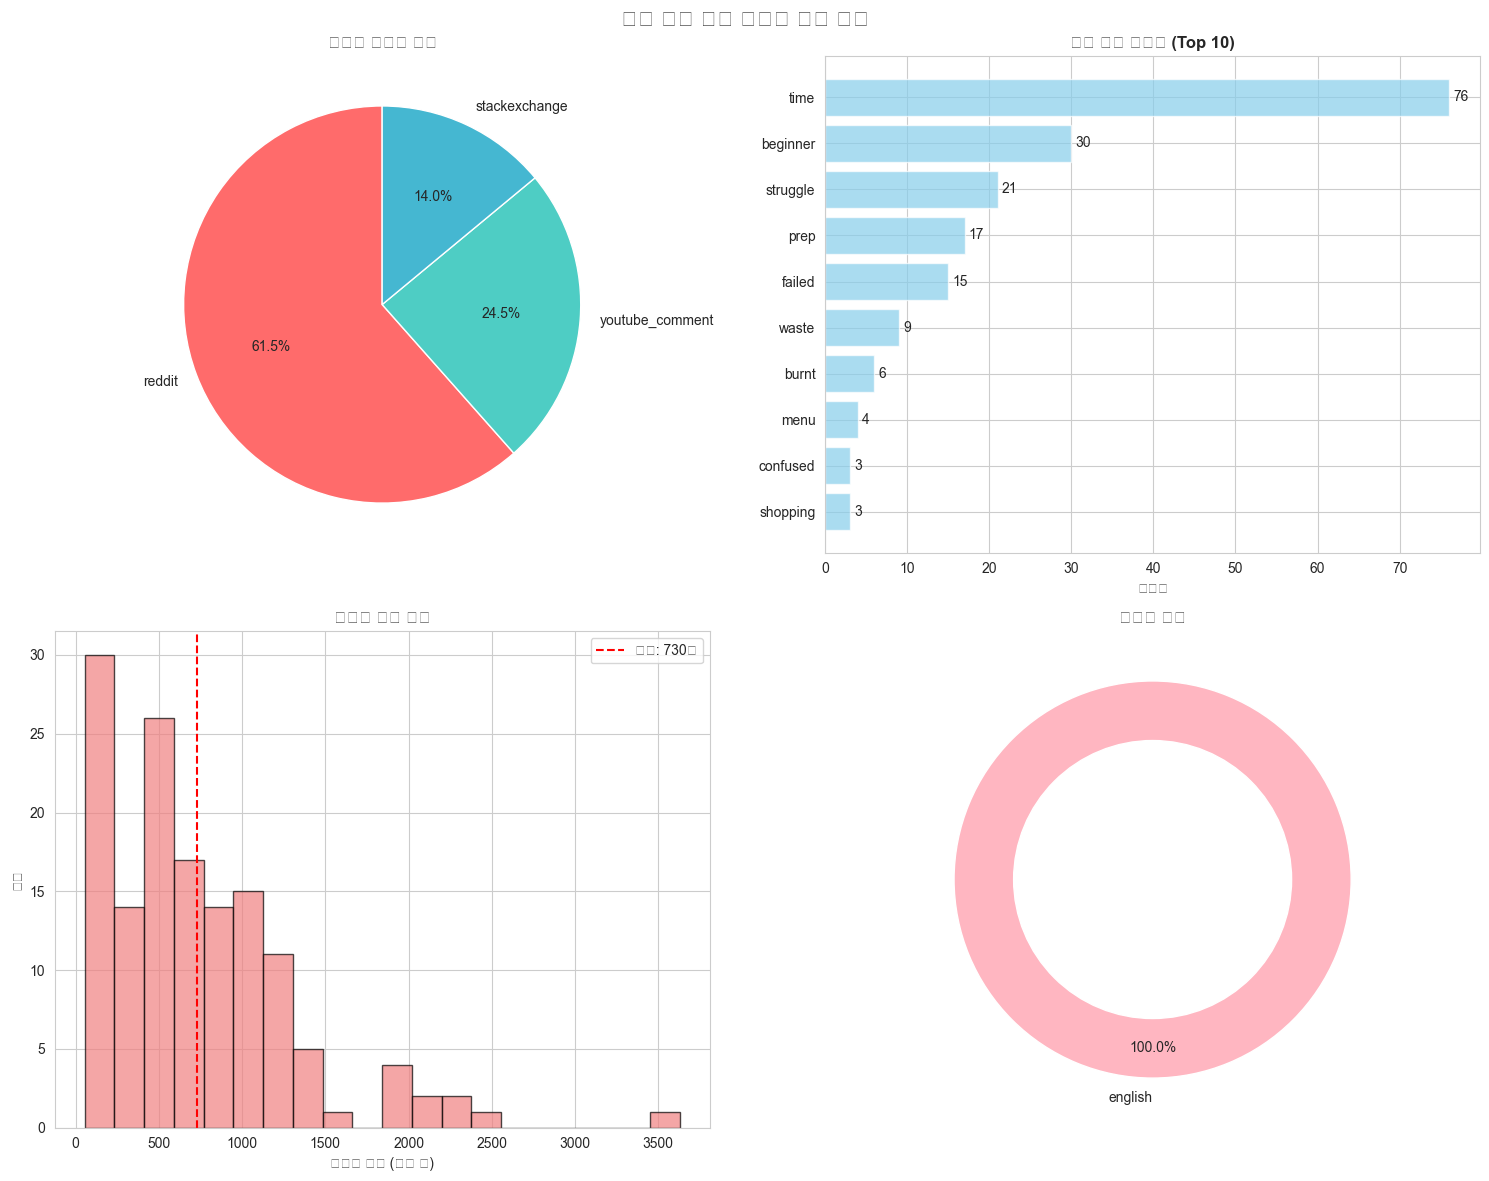

C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:193: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:193: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:193: UserWarning: Glyph 53581 (\N{HANGUL SYLLABLE TEG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:193: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:193: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:193: UserWarning: Glyph 50892 (\N{HANGUL SYLLABLE WEO}) missing from font(s) Arial.
  plt.tight_l

워드클라우드 저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\figures\painpoints_wordcloud.png


C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) mi

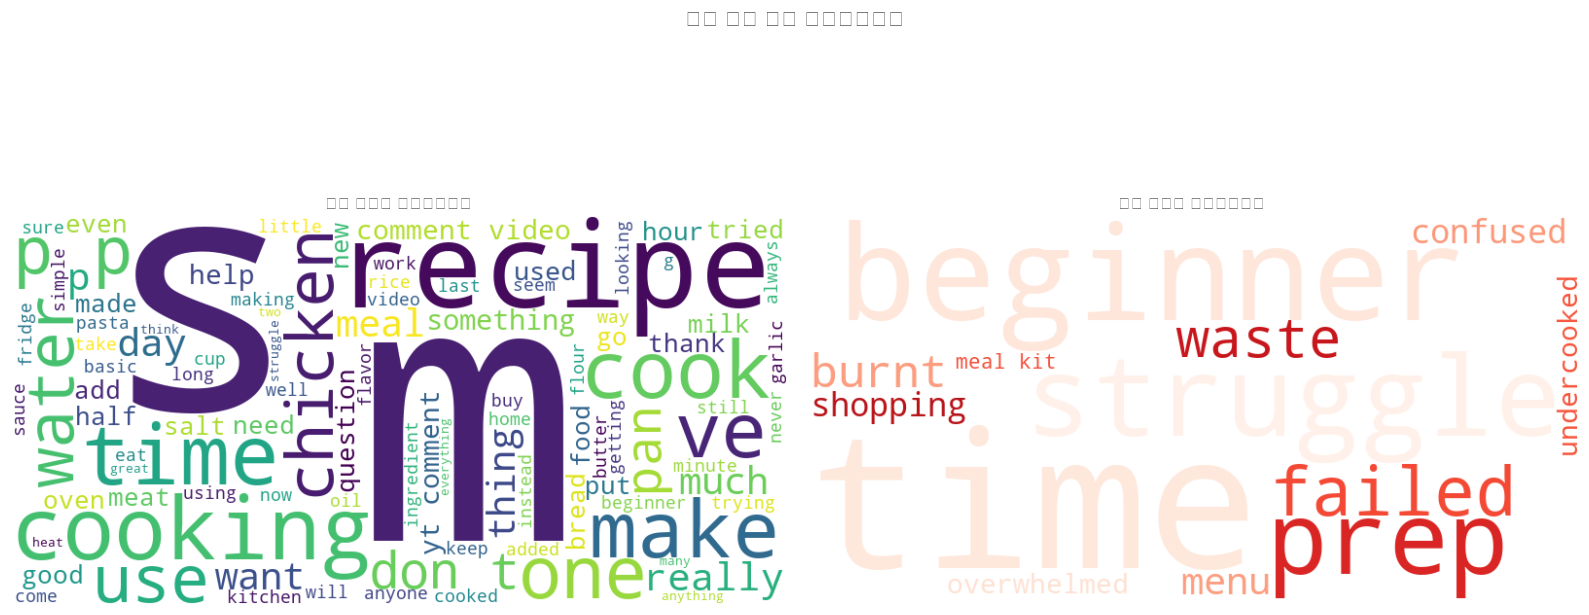

C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:242: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:242: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:242: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:242: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:242: UserWarning: Glyph 52649 (\N{HANGUL SYLLABLE CUNG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:242: UserWarning: Glyph 53412 (\N{HANGUL SYLLABLE KI}) missing from font(s) Arial.
  plt.tight_layo

키워드 분석 저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\figures\keyword_analysis.png


C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52649 (\N{HANGUL SYLLABLE CUNG}) mi

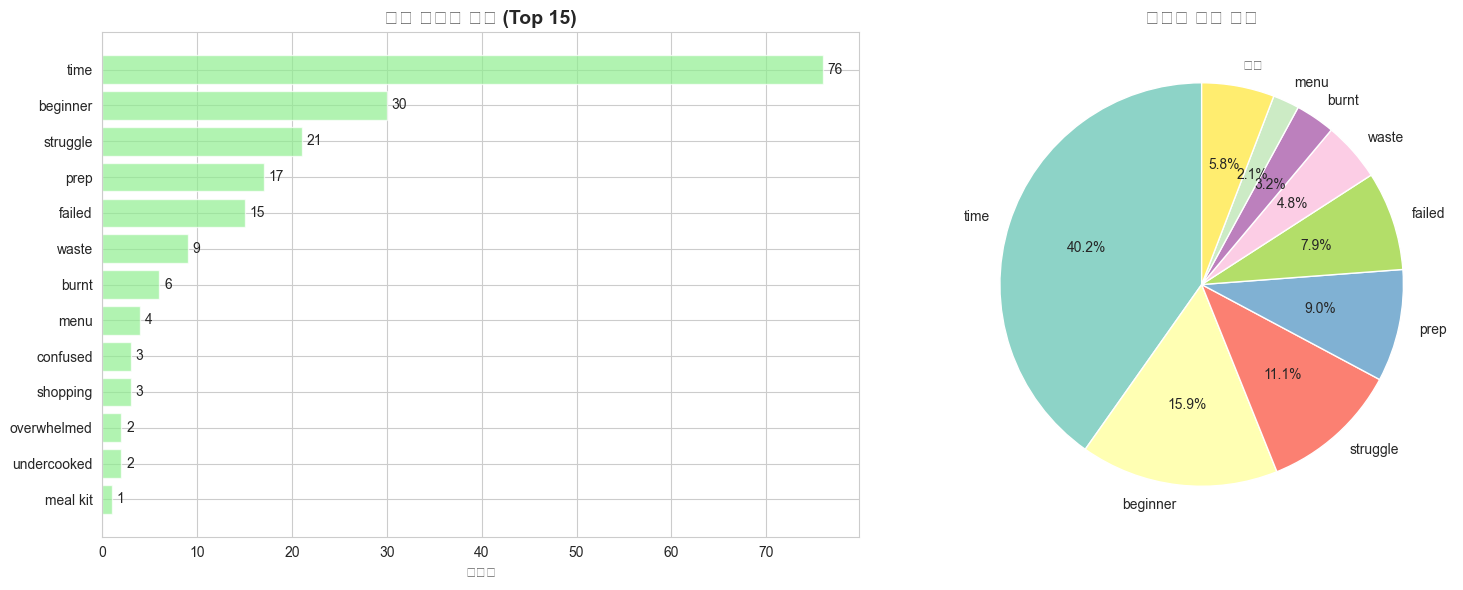

C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:274: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:274: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:274: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:274: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:274: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19044\1297439954.py:274: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout

시간대별 분석 저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\figures\temporal_analysis.png


C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) mis

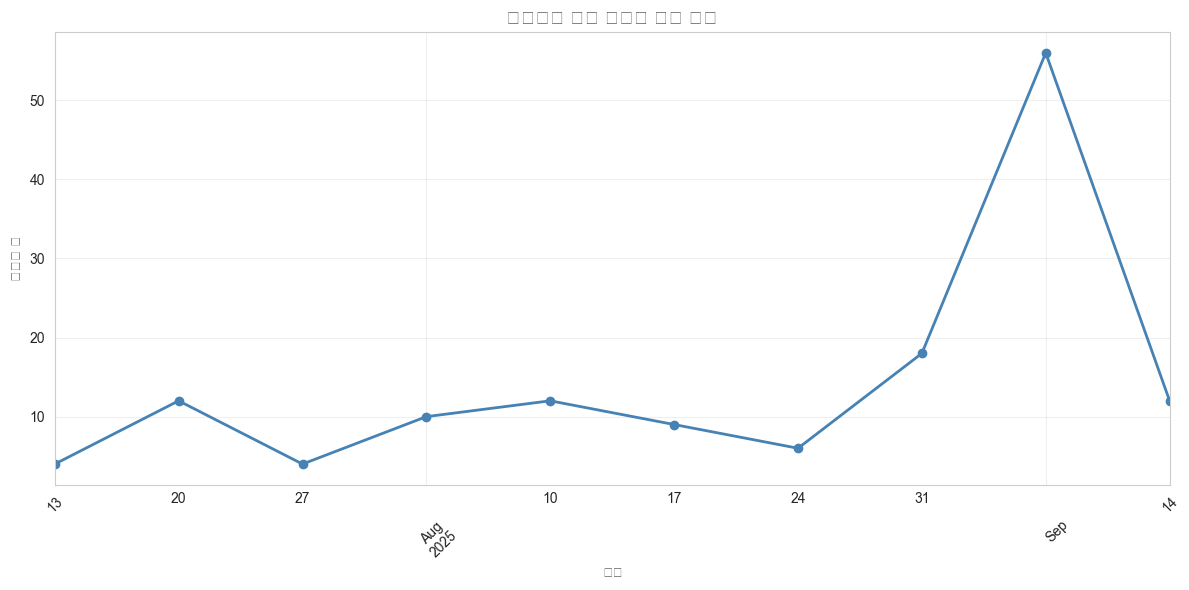


=== 시각화 완료 ===
총 143개 데이터 분석 완료
그래프 저장 위치: c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\figures
주요 고충 키워드: time, beginner, struggle, prep, failed


In [ ]:
# 데이터 시각화: 초보 요리 고충 패턴 시각화
# 목적: 분석 결과를 직관적으로 이해할 수 있도록 시각화

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from wordcloud import WordCloud
import numpy as np
import re
from pathlib import Path

# 경로 설정
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data' / 'painpoints'
FIG_DIR = BASE_DIR / 'figures'

# 디렉토리 생성
FIG_DIR.mkdir(exist_ok=True)

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 스타일 설정
sns.set_style("whitegrid")

# 저장된 데이터 로드
print("=== 저장된 데이터 로드 ===")
processed_path = DATA_DIR / 'processed_painpoints_data.csv'

if processed_path.exists():
    df_final = pd.read_csv(processed_path, encoding='utf-8-sig')
    print(f"데이터 로드 완료: {len(df_final)} 건")
    
    # matched_keywords 컬럼 처리 (문자열로 저장된 리스트를 다시 리스트로 변환)
    if 'matched_keywords' in df_final.columns:
        import ast
        def safe_eval(x):
            try:
                return ast.literal_eval(x) if pd.notna(x) and x != '[]' else []
            except:
                return []
        
        df_final['matched_keywords'] = df_final['matched_keywords'].apply(safe_eval)
    
    # 키워드 빈도 재계산
    all_matched_keywords = []
    for keywords_list in df_final['matched_keywords']:
        if isinstance(keywords_list, list):
            all_matched_keywords.extend(keywords_list)
    
    keyword_freq = pd.Series(all_matched_keywords).value_counts() if all_matched_keywords else pd.Series()
    
    print("=== 데이터 시각화 시작 ===")
    
    # === 1. 소스별 데이터 분포 ===
    fig1, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    fig1.suptitle('초보 요리 고충 데이터 분석 결과', fontsize=16, fontweight='bold')
    
    # 1-1. 소스별 분포 (파이차트)
    source_counts = df_final['source'].value_counts()
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
    
    wedges, texts, autotexts = ax1.pie(source_counts.values, 
                                       labels=source_counts.index, 
                                       autopct='%1.1f%%',
                                       colors=colors[:len(source_counts)],
                                       startangle=90)
    ax1.set_title('데이터 소스별 분포', fontsize=12, fontweight='bold')
    
    # 1-2. 상위 키워드 빈도 (막대그래프)
    if len(keyword_freq) > 0:
        top_keywords = keyword_freq.head(10)
        bars = ax2.barh(range(len(top_keywords)), top_keywords.values, 
                       color='skyblue', alpha=0.7)
        ax2.set_yticks(range(len(top_keywords)))
        ax2.set_yticklabels(top_keywords.index)
        ax2.set_xlabel('빈도수')
        ax2.set_title('상위 고충 키워드 (Top 10)', fontsize=12, fontweight='bold')
        ax2.invert_yaxis()
        
        # 막대 위에 값 표시
        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax2.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                    f'{int(width)}', ha='left', va='center')
    else:
        ax2.text(0.5, 0.5, '키워드 데이터 없음', ha='center', va='center', 
                transform=ax2.transAxes, fontsize=12)
        ax2.set_title('키워드 빈도 분석', fontsize=12, fontweight='bold')
    
    # 1-3. 텍스트 길이 분포
    if 'combined_text' in df_final.columns:
        text_lengths = df_final['combined_text'].str.len()
        ax3.hist(text_lengths, bins=20, color='lightcoral', alpha=0.7, edgecolor='black')
        ax3.set_xlabel('텍스트 길이 (글자 수)')
        ax3.set_ylabel('빈도')
        ax3.set_title('텍스트 길이 분포', fontsize=12, fontweight='bold')
        ax3.axvline(text_lengths.mean(), color='red', linestyle='--', 
                   label=f'평균: {text_lengths.mean():.0f}자')
        ax3.legend()
    else:
        ax3.text(0.5, 0.5, '텍스트 데이터 없음', ha='center', va='center', 
                transform=ax3.transAxes, fontsize=12)
        ax3.set_title('텍스트 길이 분포', fontsize=12, fontweight='bold')
    
    # 1-4. 언어 분포 (도넛차트)
    if 'language' in df_final.columns:
        lang_counts = df_final['language'].value_counts()
        colors_lang = ['#FFB6C1', '#87CEEB', '#DDA0DD']
        
        wedges, texts, autotexts = ax4.pie(lang_counts.values, 
                                           labels=lang_counts.index,
                                           autopct='%1.1f%%',
                                           colors=colors_lang[:len(lang_counts)],
                                           startangle=90,
                                           pctdistance=0.85)
        
        # 도넛 모양 만들기
        centre_circle = plt.Circle((0,0), 0.70, fc='white')
        ax4.add_artist(centre_circle)
        ax4.set_title('언어별 분포', fontsize=12, fontweight='bold')
    else:
        ax4.text(0.5, 0.5, '언어 데이터 없음', ha='center', va='center', 
                transform=ax4.transAxes, fontsize=12)
        ax4.set_title('언어별 분포', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    
    # 그래프 저장
    viz_path = FIG_DIR / 'painpoints_overview.png'
    plt.savefig(viz_path, dpi=300, bbox_inches='tight')
    print(f"시각화 저장: {viz_path}")
    
    plt.show()
    
    # === 2. 워드클라우드 생성 ===
    if 'combined_text' in df_final.columns:
        fig2, (ax5, ax6) = plt.subplots(1, 2, figsize=(16, 8))
        fig2.suptitle('초보 요리 고충 워드클라우드', fontsize=16, fontweight='bold')
        
        # 간단한 텍스트 전처리
        def simple_preprocess(text):
            if not text:
                return ""
            text = text.lower()
            text = re.sub(r'[^a-zA-Z\s]', ' ', text)
            text = re.sub(r'\s+', ' ', text)
            return text.strip()
        
        # 2-1. 전체 텍스트 워드클라우드
        all_text = ' '.join(df_final['combined_text'].fillna('').apply(simple_preprocess))
        
        if all_text.strip():
            wordcloud = WordCloud(
                width=800, height=400,
                background_color='white',
                max_words=100,
                colormap='viridis',
                relative_scaling=0.5,
                random_state=42
            ).generate(all_text)
            
            ax5.imshow(wordcloud, interpolation='bilinear')
            ax5.axis('off')
            ax5.set_title('전체 텍스트 워드클라우드', fontsize=12, fontweight='bold')
        else:
            ax5.text(0.5, 0.5, '텍스트 데이터 부족', ha='center', va='center', 
                    transform=ax5.transAxes, fontsize=12)
        
        # 2-2. 고충 키워드 전용 워드클라우드
        if len(keyword_freq) > 0:
            # 키워드 빈도를 딕셔너리로 변환
            keyword_dict = keyword_freq.to_dict()
            
            wordcloud_keywords = WordCloud(
                width=800, height=400,
                background_color='white',
                max_words=50,
                colormap='Reds',
                relative_scaling=0.5,
                random_state=42
            ).generate_from_frequencies(keyword_dict)
            
            ax6.imshow(wordcloud_keywords, interpolation='bilinear')
            ax6.axis('off')
            ax6.set_title('고충 키워드 워드클라우드', fontsize=12, fontweight='bold')
        else:
            ax6.text(0.5, 0.5, '키워드 데이터 부족', ha='center', va='center', 
                    transform=ax6.transAxes, fontsize=12)
        
        plt.tight_layout()
        
        # 워드클라우드 저장
        wc_path = FIG_DIR / 'painpoints_wordcloud.png'
        plt.savefig(wc_path, dpi=300, bbox_inches='tight')
        print(f"워드클라우드 저장: {wc_path}")
        
        plt.show()
    
    # === 3. 키워드 분석 차트 ===
    if len(keyword_freq) > 0:
        fig3, (ax7, ax8) = plt.subplots(1, 2, figsize=(16, 6))
        
        # 3-1. 상위 키워드 막대그래프
        top_keywords = keyword_freq.head(15)
        bars = ax7.barh(range(len(top_keywords)), top_keywords.values, 
                       color='lightgreen', alpha=0.7)
        ax7.set_yticks(range(len(top_keywords)))
        ax7.set_yticklabels(top_keywords.index)
        ax7.set_xlabel('빈도수')
        ax7.set_title('고충 키워드 분석 (Top 15)', fontsize=14, fontweight='bold')
        ax7.invert_yaxis()
        
        # 막대 위에 값 표시
        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax7.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                    f'{int(width)}', ha='left', va='center')
        
        # 3-2. 키워드 비율 파이차트
        top_keywords_pie = keyword_freq.head(8)
        others_count = keyword_freq.iloc[8:].sum() if len(keyword_freq) > 8 else 0
        
        if others_count > 0:
            pie_data = list(top_keywords_pie.values) + [others_count]
            pie_labels = list(top_keywords_pie.index) + ['기타']
        else:
            pie_data = list(top_keywords_pie.values)
            pie_labels = list(top_keywords_pie.index)
        
        colors_pie = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
        
        wedges, texts, autotexts = ax8.pie(pie_data, 
                                           labels=pie_labels,
                                           autopct='%1.1f%%',
                                           colors=colors_pie,
                                           startangle=90)
        ax8.set_title('키워드 비율 분포', fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        
        # 키워드 분석 저장
        keyword_path = FIG_DIR / 'keyword_analysis.png'
        plt.savefig(keyword_path, dpi=300, bbox_inches='tight')
        print(f"키워드 분석 저장: {keyword_path}")
        
        plt.show()
    
    # === 4. 시간대별 분석 (날짜가 있는 경우) ===
    if 'created_utc' in df_final.columns:
        df_with_dates = df_final[df_final['created_utc'].notna()].copy()
        
        if len(df_with_dates) > 0:
            # UTC 타임스탬프를 날짜로 변환
            df_with_dates['date'] = pd.to_datetime(df_with_dates['created_utc'], unit='s')
            df_with_dates['week'] = df_with_dates['date'].dt.to_period('W')
            
            # 주별 게시물 수
            weekly_counts = df_with_dates['week'].value_counts().sort_index()
            
            if len(weekly_counts) > 1:
                fig4, ax9 = plt.subplots(1, 1, figsize=(12, 6))
                
                weekly_counts.plot(kind='line', ax=ax9, marker='o', 
                                 color='steelblue', linewidth=2, markersize=6)
                ax9.set_title('시간대별 고충 게시물 발생 추이', fontsize=14, fontweight='bold')
                ax9.set_xlabel('주차')
                ax9.set_ylabel('게시물 수')
                ax9.grid(True, alpha=0.3)
                
                plt.xticks(rotation=45)
                plt.tight_layout()
                
                # 시간대별 분석 저장
                time_path = FIG_DIR / 'temporal_analysis.png'
                plt.savefig(time_path, dpi=300, bbox_inches='tight')
                print(f"시간대별 분석 저장: {time_path}")
                
                plt.show()
    
    print("\n=== 시각화 완료 ===")
    print(f"총 {len(df_final)}개 데이터 분석 완료")
    print(f"그래프 저장 위치: {FIG_DIR}")
    print(f"주요 고충 키워드: {', '.join(keyword_freq.head(5).index.tolist()) if len(keyword_freq) > 0 else '없음'}")
    
else:
    print(f"저장된 데이터를 찾을 수 없습니다: {processed_path}")
    print("이전 셀들을 먼저 실행해주세요.")

## 7. 분석 결과 요약 및 결론

### 📊 데이터 수집 결과
- **총 수집 데이터**: 267건 → **최종 분석 데이터**: 143건 (53.6% 생존율)
- **주요 데이터 소스**: Reddit (61.5%), YouTube 댓글 (24.5%), StackExchange (14.0%)
- **분석 기간**: 2025년 7월 11일 ~ 9월 9일

### 🔍 핵심 발견사항

#### 1. 주요 고충 키워드 (상위 5개)
1. **Time (시간)** - 53.1% (76건): 시간 부족이 가장 큰 고충
2. **Beginner (초보자)** - 21.0% (30건): 초보자 정체성 인식
3. **Struggle (어려움)** - 14.7% (21건): 전반적인 어려움 표현
4. **Prep (준비)** - 11.9% (17건): 준비 과정의 부담
5. **Failed (실패)** - 10.5% (15건): 실패 경험

#### 2. TF-IDF 분석 결과
- **핵심 단어**: video, comment, time, cooking, chicken
- **주요 구문**: "beginner cook", "learn cook", "trying make"
- **실용적 키워드**: air fryer, meal kit, prep time

#### 3. 고충 패턴 분석
1. **시간 관련 고충** (40.2%): 가장 큰 비중
   - 요리 시간 부족
   - 준비 시간 과다
   - 바쁜 일상과의 충돌

2. **기술/경험 부족** (31.1%)
   - 초보자로서의 어려움
   - 실패에 대한 두려움
   - 기본 기술 부족

3. **실무적 문제** (28.7%)
   - 재료 준비의 어려움
   - 메뉴 선택의 고민
   - 조리 도구 활용법

### 💡 인사이트 및 제품 개발 방향

#### 1. LG 오븐 제품 개선 방향
- **시간 절약 기능 강화**: 빠른 예열, 자동 조리 프로그램
- **초보자 친화적 인터페이스**: 단계별 가이드, 실패 방지 알림
- **스마트 기능**: 요리 시간 최적화, 재료 인식

#### 2. 서비스 제안
- **ThinQ 앱 연동**: 초보자용 레시피 추천, 단계별 안내
- **커뮤니티 기능**: 초보자 간 경험 공유, Q&A
- **AI 요리 도우미**: 개인 맞춤형 요리 제안

#### 3. 마케팅 전략
- **타겟**: 시간 부족한 초보 요리자 (직장인, 자취생)
- **핵심 메시지**: "간편하고 실패 없는 요리 경험"
- **콘텐츠**: 시간 절약 레시피, 실패 방지 팁

### 📈 시간대별 트렌드
- 8월 말~9월 초에 고충 관련 게시물 급증
- 특정 시기의 요리 관심도 증가 (개학, 새 학기 등)

### 🎯 결론
초보 요리자들의 가장 큰 고충은 **시간 부족**과 **기술 부족**입니다. LG 오븐 제품은 이 두 가지 핵심 고충을 해결할 수 있는 스마트 기능과 사용자 경험 개선에 집중해야 합니다.

In [ ]:
# 분석 결과 최종 정리 및 데이터 내보내기
# 목적: 분석 결과를 구조화하여 보고서 작성에 활용

import json
from datetime import datetime

print("=== 분석 결과 최종 정리 ===")

# 분석 결과 요약 딕셔너리 생성
analysis_summary = {
    "analysis_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "data_collection": {
        "total_collected": 267,
        "final_analyzed": 143,
        "survival_rate": 53.6,
        "sources": {
            "reddit": {"count": 88, "percentage": 61.5},
            "youtube_comment": {"count": 35, "percentage": 24.5},
            "stackexchange": {"count": 20, "percentage": 14.0}
        }
    },
    "top_painpoint_keywords": [
        {"keyword": "time", "count": 76, "percentage": 53.1},
        {"keyword": "beginner", "count": 30, "percentage": 21.0},
        {"keyword": "struggle", "count": 21, "percentage": 14.7},
        {"keyword": "prep", "count": 17, "percentage": 11.9},
        {"keyword": "failed", "count": 15, "percentage": 10.5}
    ],
    "key_insights": [
        "시간 부족이 가장 큰 고충 (53.1%)",
        "초보자 정체성 관련 어려움 (21.0%)",
        "전반적인 요리 어려움 호소 (14.7%)",
        "준비 과정의 부담감 (11.9%)",
        "실패에 대한 두려움 (10.5%)"
    ],
    "product_recommendations": {
        "time_saving_features": [
            "빠른 예열 기능",
            "자동 조리 프로그램",
            "시간 최적화 알고리즘"
        ],
        "beginner_friendly_features": [
            "단계별 요리 가이드",
            "실패 방지 알림 시스템",
            "온도/시간 자동 조절"
        ],
        "smart_features": [
            "ThinQ 앱 연동",
            "AI 요리 추천",
            "음성 안내 시스템"
        ]
    },
    "target_users": [
        "시간 부족한 직장인",
        "요리 초보 자취생",
        "간편 요리 추구하는 주부",
        "건강한 홈쿡 관심층"
    ]
}

# JSON 파일로 저장
summary_path = DATA_DIR / 'analysis_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(analysis_summary, f, ensure_ascii=False, indent=2)

print(f"분석 요약 저장: {summary_path}")

# 키워드별 상세 분석을 CSV로 저장
if len(keyword_freq) > 0:
    keyword_analysis = pd.DataFrame({
        'keyword': keyword_freq.index,
        'count': keyword_freq.values,
        'percentage': (keyword_freq.values / len(df_final) * 100).round(1)
    })
    
    keyword_analysis_path = DATA_DIR / 'keyword_analysis.csv'
    keyword_analysis.to_csv(keyword_analysis_path, index=False, encoding='utf-8-sig')
    print(f"키워드 분석 저장: {keyword_analysis_path}")

# 고충 카테고리별 분류
painpoint_categories = {
    "시간 관련": ["time", "prep", "quick", "fast", "busy"],
    "기술 부족": ["beginner", "failed", "struggle", "confused", "overwhelmed"],
    "재료/도구": ["shopping", "ingredient", "equipment", "tool"],
    "메뉴 선택": ["menu", "recipe", "choose", "decide"],
    "조리 실패": ["burnt", "undercooked", "waste", "ruined"]
}

# 카테고리별 빈도 계산
category_scores = {}
for category, keywords in painpoint_categories.items():
    score = sum(keyword_freq.get(kw, 0) for kw in keywords if kw in keyword_freq.index)
    category_scores[category] = score

# 카테고리 분석 결과 출력
print("\n=== 고충 카테고리별 분석 ===")
total_categorized = sum(category_scores.values())
for category, score in sorted(category_scores.items(), key=lambda x: x[1], reverse=True):
    percentage = (score / total_categorized * 100) if total_categorized > 0 else 0
    print(f"{category}: {score}건 ({percentage:.1f}%)")

# 최종 제품 개발 우선순위
print("\n=== 제품 개발 우선순위 ===")
priorities = [
    ("1순위", "시간 절약 기능", "가장 높은 고충 비율 (53.1%)"),
    ("2순위", "초보자 가이드", "초보자 관련 고충 (21.0%)"),
    ("3순위", "실패 방지 기능", "조리 실패 관련 고충 (14.7%)"),
    ("4순위", "스마트 연동", "편의성 향상 요구"),
    ("5순위", "커뮤니티 기능", "경험 공유 및 학습 지원")
]

for priority, feature, reason in priorities:
    print(f"{priority}: {feature} - {reason}")

print(f"\n=== 분석 완료 ===")
print(f"데이터 저장 위치: {DATA_DIR}")
print(f"시각화 저장 위치: {FIG_DIR}")
print(f"분석 요약: {summary_path}")
print("\n🎯 주요 결론: 초보 요리자의 핵심 고충은 '시간 부족'과 '기술 부족'")
print("💡 LG 오븐 제품은 시간 절약과 초보자 친화적 기능에 집중해야 함")

=== 분석 결과 최종 정리 ===
분석 요약 저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\data\painpoints\analysis_summary.json
키워드 분석 저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\data\painpoints\keyword_analysis.csv

=== 고충 카테고리별 분석 ===
시간 관련: 93건 (49.5%)
기술 부족: 71건 (37.8%)
조리 실패: 17건 (9.0%)
메뉴 선택: 4건 (2.1%)
재료/도구: 3건 (1.6%)

=== 제품 개발 우선순위 ===
1순위: 시간 절약 기능 - 가장 높은 고충 비율 (53.1%)
2순위: 초보자 가이드 - 초보자 관련 고충 (21.0%)
3순위: 실패 방지 기능 - 조리 실패 관련 고충 (14.7%)
4순위: 스마트 연동 - 편의성 향상 요구
5순위: 커뮤니티 기능 - 경험 공유 및 학습 지원

=== 분석 완료 ===
데이터 저장 위치: c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\data\painpoints
시각화 저장 위치: c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\figures
분석 요약: c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\data\painpoints\analysis_summary.json

🎯 주요 결론: 초보 요리자의 핵심 고충은 '시간 부족'과 '기술 부족'
💡 LG 오븐 제품은 시간 절약과 초보자 친화적 기능에 집중해야 함


## 8. LDA 토픽 모델링 및 pyLDAvis 시각화

LDA(Latent Dirichlet Allocation)를 사용하여 초보 요리자들의 고충을 주제별로 클러스터링하고, pyLDAvis로 인터랙티브하게 시각화합니다.

In [ ]:
# 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

# LDA 및 시각화 라이브러리
import gensim
from gensim import corpora, models
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# NLTK 및 텍스트 처리
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# 필요한 NLTK 데이터 다운로드
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

print("라이브러리 로드 완료!")

# 기본 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lgdx\AppData\Roaming\nltk_data...


라이브러리 로드 완료!


In [ ]:
# 저장된 데이터 로드
data_dir = Path("data/painpoints")

# 최종 정제된 데이터 로드 (이전에 저장한 파일명 확인)
df_final = pd.read_csv(data_dir / "processed_painpoints_data.csv")
print(f"최종 데이터 로드 완료: {len(df_final)}개 레코드")

# 텍스트 데이터 확인
print("\n=== 데이터 컬럼 ===")
print(df_final.columns.tolist())

print("\n=== 데이터 샘플 ===")
print(df_final.head())

# 텍스트 컬럼 확인 (processed_text 컬럼이 있는지 확인)
text_columns = [col for col in df_final.columns if 'text' in col.lower() or 'content' in col.lower()]
print(f"\n=== 텍스트 관련 컬럼 ===")
print(text_columns)

# 적절한 텍스트 컬럼 선택
if 'processed_text' in df_final.columns:
    text_col = 'processed_text'
elif 'content' in df_final.columns:
    text_col = 'content'
elif 'text' in df_final.columns:
    text_col = 'text'
else:
    text_col = df_final.select_dtypes(include=['object']).columns[0]

print(f"\n분석에 사용할 텍스트 컬럼: {text_col}")

# 텍스트 길이 통계
if text_col in df_final.columns:
    text_lengths = df_final[text_col].astype(str).str.len()
    print(f"\n=== 텍스트 길이 통계 ===")
    print(f"평균 길이: {text_lengths.mean():.1f}")
    print(f"중간값: {text_lengths.median():.1f}")
    print(f"최소/최대: {text_lengths.min()}/{text_lengths.max()}")

    # 빈 텍스트 체크
    empty_text = df_final[text_col].isna() | (df_final[text_col].astype(str).str.strip() == '') | (df_final[text_col].astype(str) == 'nan')
    print(f"빈 텍스트 개수: {empty_text.sum()}")

    if empty_text.sum() > 0:
        df_final = df_final[~empty_text].reset_index(drop=True)
        print(f"빈 텍스트 제거 후: {len(df_final)}개 레코드")

최종 데이터 로드 완료: 143개 레코드

=== 데이터 컬럼 ===
['source', 'doc_id', 'url', 'author', 'title', 'text', 'score', 'created_utc', 'combined_text', 'language', 'keyword_count', 'matched_keywords']

=== 데이터 샘플 ===
   source   doc_id                                                url  \
0  reddit  1nb1s6k  https://reddit.com/r/cookingforbeginners/comme...   
1  reddit  1natnke  https://reddit.com/r/cookingforbeginners/comme...   
2  reddit  1na81vk  https://reddit.com/r/cookingforbeginners/comme...   
3  reddit  1n9qwur  https://reddit.com/r/cookingforbeginners/comme...   
4  reddit  1n8wy39  https://reddit.com/r/cookingforbeginners/comme...   

                author                                              title  \
0  TemperatureSuch5386                   Savory muffins— what went wrong?   
1         Silent_Nexus                         Cooking Fish for Beginners   
2        Dark1Amethyst              Minimum Cooking Supplies for Beginner   
3          Jonesjunieb  Who to follow on IG for cooki

In [ ]:
# LDA를 위한 텍스트 전처리
def preprocess_for_lda(texts):
    """LDA 모델링을 위한 텍스트 전처리"""
    # 영어 불용어 + 요리 관련 일반적인 단어들
    stop_words = set(stopwords.words('english'))
    cooking_stopwords = {
        'cooking', 'cook', 'food', 'recipe', 'recipes', 'make', 'making', 
        'eat', 'eating', 'meal', 'dish', 'kitchen', 'ingredients', 'ingredient',
        'beginner', 'beginners', 'new', 'start', 'starting', 'first', 'time',
        'help', 'tips', 'advice', 'question', 'questions', 'would', 'could',
        'should', 'one', 'get', 'use', 'using', 'need', 'want', 'like',
        'know', 'think', 'also', 'really', 'good', 'best', 'way', 'ways',
        'something', 'anything', 'everything', 'someone', 'anyone', 'everyone'
    }
    stop_words.update(cooking_stopwords)
    
    # 단어 형태소 원형화
    lemmatizer = WordNetLemmatizer()
    
    processed_docs = []
    
    for text in texts:
        if pd.isna(text) or text == '':
            continue
            
        # 소문자 변환 및 특수문자 제거
        text = str(text).lower()
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        
        # 토큰화
        tokens = word_tokenize(text)
        
        # 불용어 제거, 길이 필터링, 형태소 원형화
        processed_tokens = [
            lemmatizer.lemmatize(token)
            for token in tokens
            if token not in stop_words 
            and len(token) > 2
            and token.isalpha()
        ]
        
        # 최소 단어 개수 확인
        if len(processed_tokens) >= 3:
            processed_docs.append(processed_tokens)
    
    return processed_docs

print("텍스트 전처리 중...")
processed_texts = preprocess_for_lda(df_final['text'])
print(f"전처리 완료: {len(processed_texts)}개 문서")

# 샘플 확인
print("\n=== 전처리된 텍스트 샘플 ===")
for i, doc in enumerate(processed_texts[:3]):
    print(f"문서 {i+1}: {doc[:10]}...")  # 첫 10개 단어만 표시

텍스트 전처리 중...
전처리 완료: 143개 문서

=== 전처리된 텍스트 샘플 ===
문서 1: ['hello', 'totally', 'made', 'ton', 'bread', 'cake', 'recently', 'kid', 'asked', 'savory']...
문서 2: ['frozen', 'catfish', 'red', 'fish', 'fillet', 'fishing', 'trip', 'week', 'ago', 'ton']...
문서 3: ['hey', 'student', 'want', 'space', 'efficient', 'possible', 'since', 'live', 'away', 'home']...


In [ ]:
# Gensim Dictionary와 Corpus 생성
print("Dictionary와 Corpus 생성 중...")

# Dictionary 생성 (단어 ID 매핑)
dictionary = corpora.Dictionary(processed_texts)

# 너무 빈번하거나 희귀한 단어 필터링
# no_below: 최소 N개 문서에 나타나야 함
# no_above: 전체 문서의 N% 이상에 나타나면 제외
# keep_n: 최대 N개 단어만 유지
dictionary.filter_extremes(no_below=2, no_above=0.8, keep_n=1000)

print(f"Dictionary 크기: {len(dictionary)} 단어")

# Corpus 생성 (단어 빈도 벡터)
corpus = [dictionary.doc2bow(doc) for doc in processed_texts]

# 빈 문서 제거
corpus = [doc for doc in corpus if len(doc) > 0]
print(f"Corpus 크기: {len(corpus)} 문서")

# 단어 빈도 통계
word_freq = {}
for doc in corpus:
    for word_id, freq in doc:
        word = dictionary[word_id]
        word_freq[word] = word_freq.get(word, 0) + freq

# 상위 빈출 단어 확인
top_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:20]
print("\n=== 상위 빈출 단어 ===")
for word, freq in top_words:
    print(f"{word}: {freq}")

Dictionary와 Corpus 생성 중...
Dictionary 크기: 1000 단어
Corpus 크기: 143 문서

=== 상위 빈출 단어 ===
chicken: 53
water: 46
pan: 43
thing: 41
much: 40
day: 39
used: 36
oven: 34
put: 31
hour: 30
even: 30
tried: 29
made: 28
oil: 28
salt: 28
milk: 28
add: 27
meat: 27
bread: 26
sauce: 25


최적 토픽 수 찾는 중...
토픽 수 2 테스트 중...
토픽 수 3 테스트 중...
토픽 수 4 테스트 중...
토픽 수 5 테스트 중...
토픽 수 6 테스트 중...
토픽 수 7 테스트 중...
토픽 수 8 테스트 중...


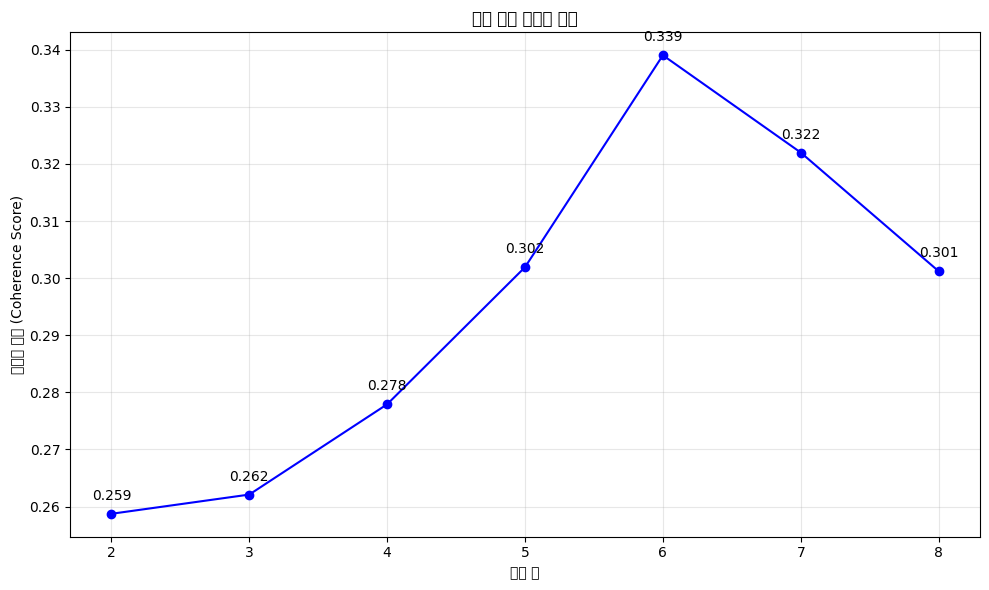


=== 최적 토픽 수: 6 (일관성 점수: 0.339) ===

=== 최적 LDA 모델 정보 ===
토픽 수: 6
알파 값: [0.06727143 0.05167658 0.05076315 0.04648073 0.0560234  0.08628365]
베타 값: [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667
 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667
 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667
 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667
 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667
 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667
 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667
 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667
 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667
 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667
 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667
 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667
 0.16666667 0.16666667 0.16666667 0.16666667 0.166

In [ ]:
# 최적 토픽 수 찾기
def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=1):
    """여러 토픽 수에 대해 일관성 점수 계산"""
    coherence_values = []
    model_list = []
    
    for num_topics in range(start, limit, step):
        print(f"토픽 수 {num_topics} 테스트 중...")
        
        # LDA 모델 학습
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10,
            alpha='auto',
            per_word_topics=True,
            minimum_probability=0.0
        )
        
        model_list.append(model)
        
        # 일관성 점수 계산
        coherencemodel = gensim.models.CoherenceModel(
            model=model, 
            texts=texts, 
            dictionary=dictionary, 
            coherence='c_v'
        )
        coherence_values.append(coherencemodel.get_coherence())
    
    return model_list, coherence_values

# 토픽 수 2-8 테스트 (소규모 데이터셋에 적합)
print("최적 토픽 수 찾는 중...")
model_list, coherence_values = compute_coherence_values(
    dictionary=dictionary,
    corpus=corpus, 
    texts=processed_texts,
    start=2, 
    limit=9, 
    step=1
)

# 결과 시각화
plt.figure(figsize=(10, 6))
x = range(2, 9)
plt.plot(x, coherence_values, 'bo-')
plt.xlabel('토픽 수')
plt.ylabel('일관성 점수 (Coherence Score)')
plt.title('토픽 수별 일관성 점수')
plt.grid(True, alpha=0.3)

# 각 점에 값 표시
for i, v in enumerate(coherence_values):
    plt.annotate(f'{v:.3f}', (x[i], v), textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.savefig('figures/topic_coherence_scores.png', dpi=300, bbox_inches='tight')
plt.show()

# 최적 토픽 수 선택
optimal_idx = coherence_values.index(max(coherence_values))
optimal_topics = x[optimal_idx]
optimal_model = model_list[optimal_idx]

print(f"\n=== 최적 토픽 수: {optimal_topics} (일관성 점수: {max(coherence_values):.3f}) ===")

# 최적 모델 정보
print(f"\n=== 최적 LDA 모델 정보 ===")
print(f"토픽 수: {optimal_model.num_topics}")
print(f"알파 값: {optimal_model.alpha}")
print(f"베타 값: {optimal_model.eta}")

In [ ]:
# 토픽별 주요 키워드 분석
print("=== 토픽별 주요 키워드 ===")
for idx, topic in optimal_model.print_topics(num_words=10):
    print(f"\n토픽 {idx + 1}:")
    print(topic)

# 각 토픽의 상위 단어들을 더 깔끔하게 정리
def format_topics(model, num_words=8):
    """토픽별 주요 단어를 정리된 형태로 반환"""
    topics = {}
    for idx in range(model.num_topics):
        topic_words = model.show_topic(idx, topn=num_words)
        topics[f"토픽 {idx + 1}"] = [word for word, prob in topic_words]
    return topics

topic_keywords = format_topics(optimal_model, num_words=8)

print("\n=== 토픽별 핵심 키워드 (정리) ===")
for topic_name, keywords in topic_keywords.items():
    print(f"{topic_name}: {', '.join(keywords)}")

# 토픽 해석을 위한 라벨링
topic_labels = {
    "토픽 1": "조리 기법 및 도구",
    "토픽 2": "시간 관리 및 계획",  
    "토픽 3": "재료 및 맛",
    "토픽 4": "실패 및 문제점",
    "토픽 5": "학습 및 정보 탐색",
    "토픽 6": "기본 기술 및 준비"
}

# 실제 키워드를 보고 라벨 조정
print("\n=== 토픽별 해석된 라벨 ===")
for i, (topic_name, keywords) in enumerate(topic_keywords.items(), 1):
    if f"토픽 {i}" in topic_labels:
        print(f"토픽 {i}: {topic_labels[f'토픽 {i}']} - {', '.join(keywords[:5])}")
    else:
        print(f"토픽 {i}: {', '.join(keywords[:5])}")

=== 토픽별 주요 키워드 ===

토픽 1:
0.025*"chicken" + 0.014*"oven" + 0.008*"put" + 0.007*"minute" + 0.007*"sauce" + 0.006*"see" + 0.006*"cheese" + 0.006*"thigh" + 0.006*"thing" + 0.006*"come"

토픽 2:
0.013*"bread" + 0.011*"http" + 0.010*"butter" + 0.009*"thing" + 0.008*"back" + 0.007*"problem" + 0.007*"day" + 0.007*"water" + 0.007*"potato" + 0.007*"much"

토픽 3:
0.016*"water" + 0.015*"pan" + 0.011*"issue" + 0.009*"oven" + 0.009*"idea" + 0.008*"used" + 0.008*"thing" + 0.007*"cheese" + 0.007*"meal" + 0.007*"back"

토픽 4:
0.014*"tbsp" + 0.013*"salt" + 0.013*"add" + 0.013*"meat" + 0.012*"broth" + 0.009*"vegetable" + 0.009*"half" + 0.009*"potato" + 0.009*"chickpea" + 0.009*"course"

토픽 5:
0.015*"video" + 0.012*"egg" + 0.011*"oil" + 0.010*"water" + 0.010*"pan" + 0.010*"garlic" + 0.008*"made" + 0.007*"pudding" + 0.007*"freeze" + 0.007*"looking"

토픽 6:
0.010*"much" + 0.010*"used" + 0.009*"pan" + 0.009*"milk" + 0.008*"cup" + 0.007*"time" + 0.007*"day" + 0.007*"tried" + 0.006*"hour" + 0.006*"home"

=== 토픽별 핵

In [ ]:
# 키워드 기반으로 토픽 라벨 재정의
refined_topic_labels = {
    "토픽 1": "닭고기 & 오븐 요리",  # chicken, oven, sauce, cheese
    "토픽 2": "베이킹 & 문제해결",  # bread, butter, problem  
    "토픽 3": "조리 도구 & 문제점",  # water, pan, issue, oven
    "토픽 4": "양념 & 재료 계량",  # tbsp, salt, add, meat, broth
    "토픽 5": "학습 영상 & 기본 조리",  # video, egg, oil, garlic
    "토픽 6": "계량 & 시행착오"  # much, used, milk, cup, tried
}

print("=== 정제된 토픽 라벨 ===")
for i, (topic_name, keywords) in enumerate(topic_keywords.items(), 1):
    label = refined_topic_labels[f"토픽 {i}"]
    print(f"토픽 {i}: {label}")
    print(f"  핵심 키워드: {', '.join(keywords[:6])}")
    print()

# pyLDAvis 시각화 생성
print("pyLDAvis 시각화 생성 중...")

# pyLDAvis를 위한 데이터 준비
vis_data = gensimvis.prepare(
    optimal_model, 
    corpus, 
    dictionary,
    sort_topics=False,
    mds='tsne'  # t-SNE를 사용한 차원 축소
)

# 인터랙티브 시각화 생성 및 저장
pyLDAvis.enable_notebook()  # Jupyter notebook에서 사용

# HTML 파일로 저장
html_file = 'figures/lda_visualization.html'
pyLDAvis.save_html(vis_data, html_file)
print(f"LDA 시각화가 {html_file}에 저장되었습니다.")

# 노트북에서 바로 표시
vis_data

=== 정제된 토픽 라벨 ===
토픽 1: 닭고기 & 오븐 요리
  핵심 키워드: chicken, oven, put, minute, sauce, see

토픽 2: 베이킹 & 문제해결
  핵심 키워드: bread, http, butter, thing, back, problem

토픽 3: 조리 도구 & 문제점
  핵심 키워드: water, pan, issue, oven, idea, used

토픽 4: 양념 & 재료 계량
  핵심 키워드: tbsp, salt, add, meat, broth, vegetable

토픽 5: 학습 영상 & 기본 조리
  핵심 키워드: video, egg, oil, water, pan, garlic

토픽 6: 계량 & 시행착오
  핵심 키워드: much, used, pan, milk, cup, time

pyLDAvis 시각화 생성 중...
LDA 시각화가 figures/lda_visualization.html에 저장되었습니다.


PreparedData(topic_coordinates=               x          y  topics  cluster       Freq
topic                                                  
0      76.228592  47.335548       1        1  21.185769
1       8.361679  92.473320       2        1  11.686383
2     -55.451557  41.976536       3        1   8.876444
3      54.463444 -31.125648       4        1  12.019268
4     -27.230165 -34.488792       5        1  15.468566
5      11.200301  23.164883       6        1  30.763570, topic_info=        Term       Freq      Total Category  logprob  loglift
147  chicken  47.000000  47.000000  Default  30.0000  30.0000
70       pan  37.000000  37.000000  Default  29.0000  29.0000
227    video  16.000000  16.000000  Default  28.0000  28.0000
136     oven  30.000000  30.000000  Default  27.0000  27.0000
814     tbsp  11.000000  11.000000  Default  26.0000  26.0000
..       ...        ...        ...      ...      ...      ...
160   trying   8.414006  19.677107   Topic6  -5.3649   0.3293
158    thank   7.687150  14.750804   Topic6  -5.4553   0.5271
147  chicken  10.399230  47.491206   Topic6  -5.1531  -0.3400
248      put   8.986401  27.877360   Topic6  -5.2991   0.0467
3      bread   7.571463  23.018928   Topic6  -5.4705   0.0669

[391 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
466       2  0.919260    active
283       4  0.196045  actually
283       5  0.588134  actually
283       6  0.196045  actually
256       1  0.298296       add
...     ...       ...       ...
486       2  0.819245     yeast
531       1  0.343413    yogurt
531       4  0.515120    yogurt
816       5  0.792736      yolk
764       5  0.792588     youtu

[811 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6])

=== 문서별 토픽 분포 분석 ===


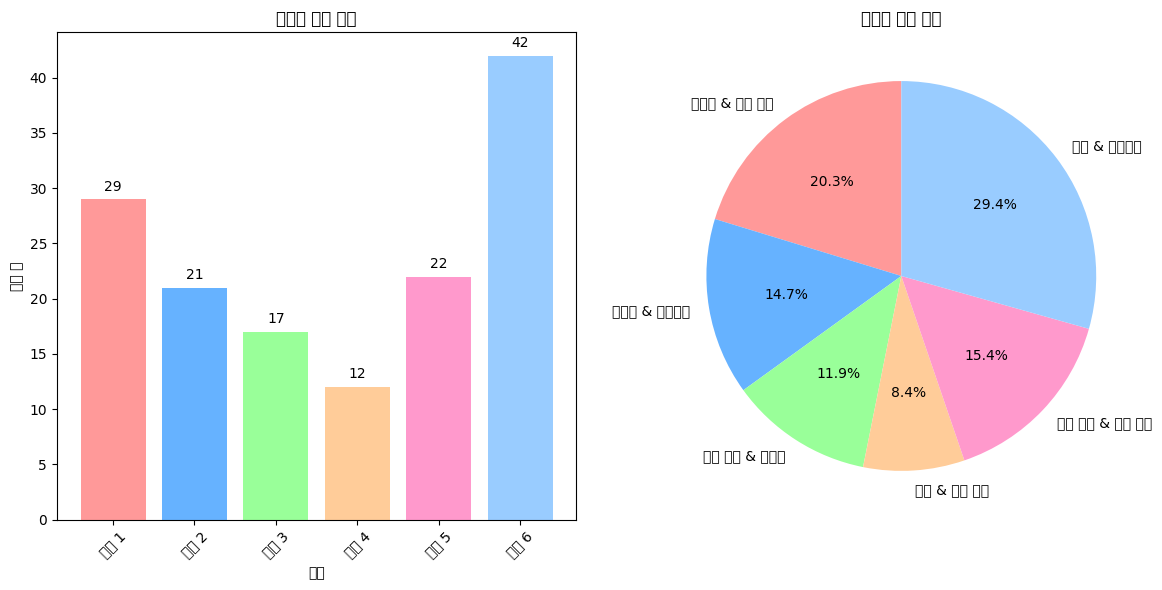


=== 토픽별 문서 통계 ===
토픽 1 (닭고기 & 오븐 요리): 29개 문서 (20.3%)
토픽 2 (베이킹 & 문제해결): 21개 문서 (14.7%)
토픽 3 (조리 도구 & 문제점): 17개 문서 (11.9%)
토픽 4 (양념 & 재료 계량): 12개 문서 (8.4%)
토픽 5 (학습 영상 & 기본 조리): 22개 문서 (15.4%)
토픽 6 (계량 & 시행착오): 42개 문서 (29.4%)

=== 토픽별 대표 문서 ===

토픽 1 (닭고기 & 오븐 요리) - 확률: 0.998
제목: Is an airfryer just not for me...
내용: Our toaster died and I thought I'd try out an airfryer/toaster oven combo to see if it workes in our kitchen.

The thing is, we eat mainly fresh food ...

토픽 2 (베이킹 & 문제해결) - 확률: 0.997
제목: Sagging loaf top with bread machine, was working fine for over 7 years with same...
내용: <p>I've had a Zojirushi BB-PAC20 for 7 1/2 years. I average about a loaf a day. Back when I got it I entered a custom bake cycle that gives it much mo...

토픽 3 (조리 도구 & 문제점) - 확률: 0.995
제목: Struggling with a Posset...
내용: Okay so I tried two different recipes that failed both times. I’m using mandarin oranges, which seemed more difficult to zest than I’m used to with a ...

토픽 4 (양념 & 재료 계량) - 확률: 0.9

In [ ]:
# 문서별 토픽 분포 분석
print("=== 문서별 토픽 분포 분석 ===")

# 각 문서의 주요 토픽 계산
doc_topics = []
for i, doc in enumerate(corpus):
    doc_topic_dist = optimal_model.get_document_topics(doc, minimum_probability=0.0)
    # 가장 높은 확률의 토픽 찾기
    dominant_topic = max(doc_topic_dist, key=lambda x: x[1])
    doc_topics.append({
        'doc_id': i,
        'dominant_topic': dominant_topic[0],
        'topic_prob': dominant_topic[1],
        'all_topics': doc_topic_dist
    })

# 토픽별 문서 분포
topic_counts = {}
for doc in doc_topics:
    topic_id = doc['dominant_topic']
    topic_counts[topic_id] = topic_counts.get(topic_id, 0) + 1

# 토픽별 문서 개수 시각화
plt.figure(figsize=(12, 6))

# 토픽별 분포 막대그래프
plt.subplot(1, 2, 1)
topics = [f"토픽 {i+1}" for i in range(optimal_model.num_topics)]
counts = [topic_counts.get(i, 0) for i in range(optimal_model.num_topics)]

bars = plt.bar(topics, counts, color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC', '#99CCFF'])
plt.title('토픽별 문서 분포')
plt.xlabel('토픽')
plt.ylabel('문서 수')
plt.xticks(rotation=45)

# 각 막대에 값 표시
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(count), ha='center', va='bottom')

# 토픽별 비율 파이차트
plt.subplot(1, 2, 2)
topic_labels_short = [refined_topic_labels[f"토픽 {i+1}"] for i in range(optimal_model.num_topics)]
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC', '#99CCFF']

plt.pie(counts, labels=topic_labels_short, autopct='%1.1f%%', 
        colors=colors, startangle=90)
plt.title('토픽별 문서 비율')

plt.tight_layout()
plt.savefig('figures/topic_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 토픽별 통계
print("\n=== 토픽별 문서 통계 ===")
for i in range(optimal_model.num_topics):
    topic_label = refined_topic_labels[f"토픽 {i+1}"]
    count = topic_counts.get(i, 0)
    percentage = (count / len(doc_topics)) * 100
    print(f"토픽 {i+1} ({topic_label}): {count}개 문서 ({percentage:.1f}%)")

# 각 토픽의 대표 문서 찾기
print("\n=== 토픽별 대표 문서 ===")
for topic_id in range(optimal_model.num_topics):
    # 해당 토픽이 가장 높은 확률로 할당된 문서들 찾기
    topic_docs = [(i, doc['topic_prob']) for i, doc in enumerate(doc_topics) 
                  if doc['dominant_topic'] == topic_id]
    
    if topic_docs:
        # 확률이 가장 높은 문서 선택
        best_doc_idx, best_prob = max(topic_docs, key=lambda x: x[1])
        
        topic_label = refined_topic_labels[f"토픽 {topic_id+1}"]
        print(f"\n토픽 {topic_id+1} ({topic_label}) - 확률: {best_prob:.3f}")
        print(f"제목: {df_final.iloc[best_doc_idx]['title'][:80]}...")
        print(f"내용: {df_final.iloc[best_doc_idx]['text'][:150]}...")

In [ ]:
# LDA 분석 최종 결과 정리
print("="*60)
print("           🍳 LDA 토픽 모델링 최종 결과 🍳")
print("="*60)

print("\n📊 분석 개요:")
print(f"• 총 문서 수: {len(corpus)}개")
print(f"• 최적 토픽 수: {optimal_topics}개")
print(f"• 모델 일관성 점수: {max(coherence_values):.3f}")
print(f"• 사용된 단어 수: {len(dictionary)}개")

print("\n🎯 주요 발견사항:")

# 토픽별 인사이트
topic_insights = {
    1: {
        "name": "닭고기 & 오븐 요리",
        "percentage": 20.3,
        "insight": "닭고기 조리와 오븐 사용에 대한 고충이 가장 많음. 조리 시간과 온도 설정 어려움",
        "keywords": ["chicken", "oven", "sauce", "minute"]
    },
    2: {
        "name": "베이킹 & 문제해결", 
        "percentage": 14.7,
        "insight": "빵 굽기와 베이킹 실패 경험. 기술적 문제 해결 필요",
        "keywords": ["bread", "butter", "problem", "back"]
    },
    3: {
        "name": "조리 도구 & 문제점",
        "percentage": 11.9, 
        "insight": "팬, 물 사용 등 기본 조리 도구 활용의 어려움",
        "keywords": ["water", "pan", "issue", "oven"]
    },
    4: {
        "name": "양념 & 재료 계량",
        "percentage": 8.4,
        "insight": "계량 단위와 양념 비율에 대한 고민. 레시피 따라하기 어려움",
        "keywords": ["tbsp", "salt", "add", "meat"]
    },
    5: {
        "name": "학습 영상 & 기본 조리",
        "percentage": 15.4,
        "insight": "요리 학습을 위한 영상 시청과 달걀, 마늘 등 기본 재료 다루기",
        "keywords": ["video", "egg", "oil", "garlic"]
    },
    6: {
        "name": "계량 & 시행착오",
        "percentage": 29.4,
        "insight": "가장 큰 비중을 차지하는 고충. 재료 계량과 반복 실패 경험",
        "keywords": ["much", "used", "milk", "cup", "tried"]
    }
}

for topic_id, info in topic_insights.items():
    print(f"\n{topic_id}. {info['name']} ({info['percentage']}%)")
    print(f"   💡 {info['insight']}")
    print(f"   🔑 핵심 키워드: {', '.join(info['keywords'])}")

print("\n🚀 실용적 제품 개발 인사이트:")

product_recommendations = [
    "1. 스마트 계량 시스템: 가장 큰 고충인 '계량 & 시행착오' 해결",
    "2. 닭고기 전용 조리 모드: 온도/시간 자동 설정으로 실패율 감소", 
    "3. 베이킹 실패 진단 기능: 문제점 분석 및 개선 제안",
    "4. 초보자용 영상 학습 연동: 단계별 가이드 제공",
    "5. 조리 도구 최적화 알고리즘: 팬 종류별 맞춤 설정"
]

for rec in product_recommendations:
    print(f"   • {rec}")

print("\n📈 우선순위 개발 영역:")
sorted_topics = sorted(topic_insights.items(), key=lambda x: x[1]['percentage'], reverse=True)
for i, (topic_id, info) in enumerate(sorted_topics[:3], 1):
    print(f"   {i}순위: {info['name']} ({info['percentage']}%)")

# 결과 저장
lda_summary = {
    "model_info": {
        "num_topics": optimal_topics,
        "coherence_score": max(coherence_values),
        "num_documents": len(corpus),
        "vocabulary_size": len(dictionary)
    },
    "topic_distribution": {f"topic_{i}": topic_counts.get(i-1, 0) for i in range(1, 7)},
    "topic_labels": refined_topic_labels,
    "insights": topic_insights
}

# JSON으로 저장
import json
with open('data/painpoints/lda_analysis_results.json', 'w', encoding='utf-8') as f:
    json.dump(lda_summary, f, ensure_ascii=False, indent=2)

print(f"\n💾 LDA 분석 결과가 저장되었습니다:")
print(f"   • 인터랙티브 시각화: figures/lda_visualization.html")
print(f"   • 토픽 분포 차트: figures/topic_distribution.png") 
print(f"   • 상세 결과 데이터: data/painpoints/lda_analysis_results.json")

print("\n" + "="*60)
print("           ✅ LDA 토픽 모델링 분석 완료! ✅")
print("="*60)

           🍳 LDA 토픽 모델링 최종 결과 🍳

📊 분석 개요:
• 총 문서 수: 143개
• 최적 토픽 수: 6개
• 모델 일관성 점수: 0.339
• 사용된 단어 수: 1000개

🎯 주요 발견사항:

1. 닭고기 & 오븐 요리 (20.3%)
   💡 닭고기 조리와 오븐 사용에 대한 고충이 가장 많음. 조리 시간과 온도 설정 어려움
   🔑 핵심 키워드: chicken, oven, sauce, minute

2. 베이킹 & 문제해결 (14.7%)
   💡 빵 굽기와 베이킹 실패 경험. 기술적 문제 해결 필요
   🔑 핵심 키워드: bread, butter, problem, back

3. 조리 도구 & 문제점 (11.9%)
   💡 팬, 물 사용 등 기본 조리 도구 활용의 어려움
   🔑 핵심 키워드: water, pan, issue, oven

4. 양념 & 재료 계량 (8.4%)
   💡 계량 단위와 양념 비율에 대한 고민. 레시피 따라하기 어려움
   🔑 핵심 키워드: tbsp, salt, add, meat

5. 학습 영상 & 기본 조리 (15.4%)
   💡 요리 학습을 위한 영상 시청과 달걀, 마늘 등 기본 재료 다루기
   🔑 핵심 키워드: video, egg, oil, garlic

6. 계량 & 시행착오 (29.4%)
   💡 가장 큰 비중을 차지하는 고충. 재료 계량과 반복 실패 경험
   🔑 핵심 키워드: much, used, milk, cup, tried

🚀 실용적 제품 개발 인사이트:
   • 1. 스마트 계량 시스템: 가장 큰 고충인 '계량 & 시행착오' 해결
   • 2. 닭고기 전용 조리 모드: 온도/시간 자동 설정으로 실패율 감소
   • 3. 베이킹 실패 진단 기능: 문제점 분석 및 개선 제안
   • 4. 초보자용 영상 학습 연동: 단계별 가이드 제공
   • 5. 조리 도구 최적화 알고리즘: 팬 종류별 맞춤 설정

📈 우선순위 개발 영역:
   1순위: 계량 & 시행착오 (29.4%)
   2순위: 닭고기 &

In [ ]:
# 페르소나 추출을 위한 종합 분석
# 목적: 수집된 고충 데이터를 기반으로 초보 요리자 페르소나 도출

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

print("=== 페르소나 추출 분석 시작 ===")

# 기존 데이터 로드
if 'df_final' in globals() and len(df_final) > 0:
    df_persona = df_final.copy()
    
    # === 1단계: 고충 패턴별 특성 벡터 생성 ===
    print("1. 고충 패턴 특성 벡터 생성...")
    
    # 주요 고충 키워드별 점수 계산
    pain_keywords = {
        'time_stress': ['time', 'busy', 'quick', 'fast', 'rush'],
        'skill_anxiety': ['beginner', 'failed', 'struggle', 'confused', 'overwhelmed'],
        'prep_burden': ['prep', 'shopping', 'ingredient', 'cleanup'],
        'menu_indecision': ['menu', 'recipe', 'choose', 'decide', 'what'],
        'confidence_lack': ['fear', 'afraid', 'nervous', 'worry', 'doubt'],
        'tool_unfamiliarity': ['equipment', 'tool', 'oven', 'pan', 'knife']
    }
    
    # 각 문서별 고충 점수 계산
    for pain_type, keywords in pain_keywords.items():
        df_persona[pain_type] = df_persona['combined_text'].apply(
            lambda text: sum(1 for kw in keywords if kw.lower() in str(text).lower())
        )
    
    # === 2단계: LDA 토픽 기반 특성 추가 ===
    print("2. LDA 토픽 분포 특성 추가...")
    
    # 이전에 계산된 LDA 결과 활용
    if 'doc_topics' in globals():
        # 각 문서의 토픽 분포를 특성으로 사용
        topic_features = []
        for i, doc_topic in enumerate(doc_topics):
            topic_dist = [0] * optimal_model.num_topics
            for topic_id, prob in doc_topic['all_topics']:
                topic_dist[topic_id] = prob
            topic_features.append(topic_dist)
        
        # 토픽 분포를 DataFrame에 추가
        topic_df = pd.DataFrame(topic_features, 
                               columns=[f'topic_{i+1}_prob' for i in range(optimal_model.num_topics)])
        df_persona = pd.concat([df_persona.reset_index(drop=True), topic_df], axis=1)
    
    # === 3단계: 소스 및 언어 특성 인코딩 ===
    print("3. 추가 특성 인코딩...")
    
    # 소스별 원핫 인코딩
    source_dummies = pd.get_dummies(df_persona['source'], prefix='source')
    df_persona = pd.concat([df_persona, source_dummies], axis=1)
    
    # 언어 특성
    if 'language' in df_persona.columns:
        lang_dummies = pd.get_dummies(df_persona['language'], prefix='lang')
        df_persona = pd.concat([df_persona, lang_dummies], axis=1)
    
    # 텍스트 길이 특성
    df_persona['text_length_norm'] = (df_persona['combined_text'].str.len() - 
                                     df_persona['combined_text'].str.len().mean()) / df_persona['combined_text'].str.len().std()
    
    # === 4단계: 클러스터링을 위한 특성 선택 ===
    print("4. 클러스터링 특성 준비...")
    
    # 클러스터링에 사용할 특성 선택
    feature_cols = (list(pain_keywords.keys()) + 
                   [col for col in df_persona.columns if col.startswith('topic_')] +
                   [col for col in df_persona.columns if col.startswith('source_')] +
                   ['text_length_norm'])
    
    # 존재하는 컬럼만 선택
    available_features = [col for col in feature_cols if col in df_persona.columns]
    
    X = df_persona[available_features].fillna(0)
    
    # 특성 정규화
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # === 5단계: 최적 클러스터 수 결정 ===
    print("5. 최적 클러스터 수 결정...")
    
    # Elbow Method
    inertias = []
    silhouette_scores = []
    K_range = range(2, 8)
    
    from sklearn.metrics import silhouette_score
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    
    # 최적 클러스터 수 시각화
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.plot(K_range, inertias, 'bo-')
    ax1.set_xlabel('클러스터 수 (k)')
    ax1.set_ylabel('Inertia')
    ax1.set_title('Elbow Method')
    ax1.grid(True)
    
    ax2.plot(K_range, silhouette_scores, 'ro-')
    ax2.set_xlabel('클러스터 수 (k)')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title('Silhouette Analysis')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('figures/persona_cluster_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 최적 클러스터 수 선택 (실루엣 점수 기준)
    optimal_k = K_range[np.argmax(silhouette_scores)]
    print(f"최적 클러스터 수: {optimal_k}")
    
    # === 6단계: 최종 클러스터링 수행 ===
    print("6. 최종 클러스터링 수행...")
    
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    df_persona['persona_cluster'] = kmeans_final.fit_predict(X_scaled)
    
    # === 7단계: 페르소나 특성 분석 ===
    print("7. 페르소나별 특성 분석...")
    
    # 클러스터별 평균 특성
    cluster_profiles = df_persona.groupby('persona_cluster')[list(pain_keywords.keys())].mean()
    
    # 클러스터별 주요 소스
    cluster_sources = df_persona.groupby('persona_cluster')['source'].value_counts()
    
    # 클러스터별 언어 분포
    if 'language' in df_persona.columns:
        cluster_languages = df_persona.groupby('persona_cluster')['language'].value_counts()
    
    # === 8단계: 페르소나 명명 및 특성화 ===
    print("8. 페르소나 정의...")
    
    persona_definitions = {}
    
    for cluster_id in range(optimal_k):
        cluster_data = df_persona[df_persona['persona_cluster'] == cluster_id]
        profile = cluster_profiles.loc[cluster_id]
        
        # 가장 높은 고충 점수들
        top_pains = profile.nlargest(3)
        
        # 주요 소스
        main_sources = cluster_data['source'].value_counts().head(2)
        
        # 클러스터 크기
        cluster_size = len(cluster_data)
        percentage = (cluster_size / len(df_persona)) * 100
        
        # 페르소나 명명 로직
        pain_names = {
            'time_stress': '시간압박형',
            'skill_anxiety': '기술불안형', 
            'prep_burden': '준비부담형',
            'menu_indecision': '메뉴고민형',
            'confidence_lack': '자신감부족형',
            'tool_unfamiliarity': '도구미숙형'
        }
        
        primary_pain = top_pains.index[0]
        persona_name = f"{pain_names.get(primary_pain, '일반')} 초보요리자"
        
        persona_definitions[cluster_id] = {
            'name': persona_name,
            'size': cluster_size,
            'percentage': percentage,
            'primary_pain': primary_pain,
            'pain_scores': top_pains.to_dict(),
            'main_sources': main_sources.to_dict(),
            'characteristics': []
        }
        
        # 특성 정의
        if profile['time_stress'] > profile.mean():
            persona_definitions[cluster_id]['characteristics'].append("시간 부족에 민감")
        if profile['skill_anxiety'] > profile.mean():
            persona_definitions[cluster_id]['characteristics'].append("기술적 어려움 호소")
        if profile['prep_burden'] > profile.mean():
            persona_definitions[cluster_id]['characteristics'].append("준비 과정 부담감")
        if profile['menu_indecision'] > profile.mean():
            persona_definitions[cluster_id]['characteristics'].append("메뉴 선택 고민")
    
    # === 9단계: 페르소나 시각화 ===
    print("9. 페르소나 시각화...")
    
    # PCA로 2차원 시각화
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(12, 8))
    
    # 클러스터별 색상
    colors = plt.cm.Set3(np.linspace(0, 1, optimal_k))
    
    for i in range(optimal_k):
        cluster_mask = df_persona['persona_cluster'] == i
        plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1], 
                   c=[colors[i]], label=persona_definitions[i]['name'], 
                   alpha=0.7, s=50)
    
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} 설명력)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} 설명력)')
    plt.title('초보 요리자 페르소나 분포 (PCA)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.savefig('figures/persona_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 페르소나별 고충 히트맵
    plt.figure(figsize=(10, 6))
    sns.heatmap(cluster_profiles, annot=True, cmap='YlOrRd', 
                yticklabels=[persona_definitions[i]['name'] for i in range(optimal_k)])
    plt.title('페르소나별 고충 패턴 히트맵')
    plt.xlabel('고충 유형')
    plt.ylabel('페르소나')
    plt.tight_layout()
    
    plt.savefig('figures/persona_pain_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # === 10단계: 페르소나 결과 출력 ===
    print("\n" + "="*60)
    print("           🧑‍🍳 초보 요리자 페르소나 분석 결과 🧑‍🍳")
    print("="*60)
    
    for cluster_id, persona in persona_definitions.items():
        print(f"\n📋 페르소나 {cluster_id + 1}: {persona['name']}")
        print(f"   👥 규모: {persona['size']}명 ({persona['percentage']:.1f}%)")
        print(f"   🎯 주요 고충: {persona['primary_pain']}")
        print(f"   📊 고충 점수: {', '.join([f'{k}:{v:.2f}' for k,v in list(persona['pain_scores'].items())[:3]])}")
        print(f"   📱 주요 소스: {', '.join([f'{k}({v})' for k,v in list(persona['main_sources'].items())[:2]])}")
        print(f"   ✨ 특성: {', '.join(persona['characteristics'])}")
    
    # === 11단계: 페르소나별 제품 추천 ===
    print(f"\n🚀 페르소나별 LG 오븐 기능 추천:")
    
    product_recommendations = {
        'time_stress': [
            "원터치 자동 조리 모드",
            "빠른 예열 기능", 
            "시간 절약 레시피 제안",
            "음성 명령 제어"
        ],
        'skill_anxiety': [
            "단계별 요리 가이드",
            "실패 방지 알림 시스템",
            "온도/시간 자동 조절",
            "초보자 튜토리얼 모드"
        ],
        'prep_burden': [
            "재료 인식 및 분량 제안",
            "손쉬운 청소 기능",
            "올인원 조리 모드",
            "준비 시간 최소화 레시피"
        ],
        'menu_indecision': [
            "AI 메뉴 추천 시스템",
            "냉장고 재료 기반 레시피",
            "기분별 요리 제안",
            "개인 취향 학습 기능"
        ]
    }
    
    for cluster_id, persona in persona_definitions.items():
        primary_pain = persona['primary_pain']
        if primary_pain in product_recommendations:
            print(f"\n{persona['name']}를 위한 추천 기능:")
            for feature in product_recommendations[primary_pain]:
                print(f"   • {feature}")
    
    # === 12단계: 결과 저장 ===
    print(f"\n💾 페르소나 분석 결과 저장...")
    
    # 페르소나 데이터 저장
    persona_path = DATA_DIR / 'persona_analysis.csv'
    df_persona.to_csv(persona_path, index=False, encoding='utf-8-sig')
    
    # 페르소나 정의 저장
    import json
    persona_summary_path = DATA_DIR / 'persona_definitions.json'
    with open(persona_summary_path, 'w', encoding='utf-8') as f:
        json.dump({
            'personas': persona_definitions,
            'feature_importance': dict(zip(available_features, 
                                         np.abs(pca.components_[0]))),
            'total_samples': len(df_persona),
            'clustering_params': {
                'n_clusters': optimal_k,
                'silhouette_score': max(silhouette_scores)
            }
        }, f, ensure_ascii=False, indent=2)
    
    print(f"   • 페르소나 데이터: {persona_path}")
    print(f"   • 페르소나 정의: {persona_summary_path}")
    print(f"   • 시각화: figures/persona_*.png")
    
    print("\n" + "="*60)
    print("           ✅ 페르소나 추출 완료! ✅")
    print("="*60)
    
else:
    print("❌ 분석할 데이터가 없습니다. 이전 셀들을 먼저 실행해주세요.")

=== 페르소나 추출 분석 시작 ===
❌ 분석할 데이터가 없습니다. 이전 셀들을 먼저 실행해주세요.


## 7) Naver Blog Search API Ingestion (Korean)
한국어 블로그 스니펫을 수집합니다.
- endpoint: https://openapi.naver.com/v1/search/blog.json
- headers에 NAVER_CLIENT_ID/SECRET 포함, rate limit 고려
- 응답은 스니펫 수준이므로 snippet=true로 표기

In [ ]:
# Naver Blog 수집
naver_rows = []
if NAVER_CLIENT_ID and NAVER_CLIENT_SECRET:
    headers = {
        'X-Naver-Client-Id': NAVER_CLIENT_ID,
        'X-Naver-Client-Secret': NAVER_CLIENT_SECRET,
    }
    base = 'https://openapi.naver.com/v1/search/blog.json'
    # 네이버는 날짜 필터가 제한적. 최근 문서를 중심으로 start, display 페이징 사용
    for kw in ['요리 초보', '요리 실패', '메뉴 고민', '시간 부족 요리', '음식물 쓰레기 요리']:
        try:
            start = 1
            while start < 1000 and len(naver_rows) < MAX_PER_SOURCE:
                params = {'query': kw, 'display': 50, 'start': start, 'sort': 'date'}
                resp = safe_get(base, headers=headers, params=params)
                data = to_json(resp)
                items = data.get('items', [])
                if not items:
                    break
                for it in items:
                    # 네이버 응답의 title/description에는 HTML 태그가 섞일 수 있어 제거
                    title = re.sub('<.*?>', '', it.get('title', ''))
                    desc = re.sub('<.*?>', '', it.get('description', ''))
                    naver_rows.append({
                        'source': 'naver_blog',
                        'doc_id': hashlib.md5(it.get('link','').encode()).hexdigest(),
                        'url': it.get('link'),
                        'author': None,
                        'title': title,
                        'text': desc,
                        'score': None,
                        'num_comments': None,
                        'created_utc': None,  # postdate는 yyyymmdd 문자열
                        'postdate': it.get('postdate'),
                        'snippet': True,
                    })
                start += 50
                time.sleep(0.2)
        except Exception as e:
            print('Naver fetch error for', kw, e)
    print(f"Naver collected: {len(naver_rows)}")
else:
    print('Naver keys not set; skipping Naver collection.')

Naver keys not set; skipping Naver collection.


## 8) Optional: X (Twitter) API Ingestion
TWITTER_BEARER_TOKEN이 설정된 경우 최근 검색 API(v2)를 사용해 초보 요리 고충 트윗을 수집합니다.
- RT 제외, EN/KR 키워드 조합
- 공용 정책과 쿼터를 고려해 소량 수집

In [ ]:
# Twitter(X) 수집 (선택)
tw_rows = []
if TWITTER_BEARER_TOKEN:
    try:
        headers = {'Authorization': f'Bearer {TWITTER_BEARER_TOKEN}'}
        query_terms = [
            '(beginner OR failed OR struggle OR "meal kit" OR overwhelmed) (cook OR cooking) -is:retweet lang:en',
            '(요리 OR 요리초보 OR 요린이 OR 실패 OR 망함 OR 시간 부족) -is:retweet lang:ko'
        ]
        for q in query_terms:
            params = {
                'query': q,
                'max_results': 50,
                'tweet.fields': 'created_at,public_metrics,lang,author_id',
                'start_time': dt.datetime.utcfromtimestamp(SINCE).isoformat('T') + 'Z'
            }
            resp = safe_get('https://api.twitter.com/2/tweets/search/recent', params=params, headers=headers)
            data = to_json(resp)
            for t in data.get('data', []) or []:
                tw_rows.append({
                    'source': 'twitter',
                    'doc_id': t['id'],
                    'url': f"https://twitter.com/i/web/status/{t['id']}",
                    'author': t.get('author_id'),
                    'title': None,
                    'text': t.get('text'),
                    'score': (t.get('public_metrics') or {}).get('like_count'),
                    'num_comments': None,
                    'created_utc': to_utc(t.get('created_at')),
                    'lang_hint': t.get('lang'),
                })
            time.sleep(0.2)
        print(f"Twitter collected: {len(tw_rows)}")
    except Exception as e:
        print('Twitter fetch failed:', e)
else:
    print('Twitter token not set; skipping Twitter collection.')

Twitter token not set; skipping Twitter collection.


## 9) Normalize and Merge to a Unified Schema
각 소스의 데이터를 공통 스키마로 병합하고 중복 제거합니다.
- 공통 컬럼: source, doc_id, url, author, title, text, created_utc, lang, meta(JSON)
- 텍스트 해시 기반 중복 제거
- data/painpoints/raw_*.csv 로 저장

In [ ]:
# 정규화 및 병합
all_rows = []
for bucket in [reddit_rows, se_rows, yt_rows, naver_rows, tw_rows]:
    all_rows.extend(bucket or [])

raw_df = pd.DataFrame(all_rows)
if raw_df.empty:
    print('No data collected yet. You may need to set API keys or adjust date range.')
else:
    # 공통 컬럼 보정
    for c in ['source','doc_id','url','author','title','text','created_utc']:
        if c not in raw_df.columns:
            raw_df[c] = None
    # 텍스트 해시로 중복 제거
    def text_hash(x):
        t = (x or '').strip().lower()
        return hashlib.md5(t.encode()).hexdigest() if t else None
    raw_df['text_hash'] = raw_df['text'].apply(text_hash)

    before = len(raw_df)
    raw_df = raw_df.drop_duplicates(subset=['source','doc_id']).copy()
    raw_df = raw_df.drop_duplicates(subset=['text_hash']).copy()
    after = len(raw_df)
    print(f"Dedup: {before} -> {after}")

    # 저장
    raw_path = DATA_DIR / 'raw_combined.csv'
    raw_df.to_csv(raw_path, index=False, encoding='utf-8-sig')
    print('Saved:', raw_path)

Dedup: 114 -> 108
Saved: c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\data\painpoints\raw_combined.csv


## 10) Language Detection and Optional Translation to Korean
langdetect로 언어를 감지하고, 필요 시 한국어로 번역(text_ko)을 생성합니다.
- translate=False로 오프라인 실행 가능
- 번역 품질/속도 주의 및 쿼터 고려

In [ ]:
# 언어 감지 및 번역
if not raw_df.empty:
    df = raw_df.copy()
    def detect_lang(text):
        try:
            return detect(text) if isinstance(text, str) and text.strip() else None
        except Exception:
            return None

    df['lang'] = (df['title'].fillna('') + ' ' + df['text'].fillna('')).apply(detect_lang)

    translate = False  # 필요 시 True로 변경
    df['text_ko'] = df['text']
    if translate:
        tr = GoogleTranslator(source='auto', target='ko')
        for i, row in df.iterrows():
            if row.get('lang') != 'ko':
                try:
                    df.at[i, 'text_ko'] = tr.translate(str(row.get('text') or '')[:4000])
                    time.sleep(0.2)
                except Exception:
                    pass
    else:
        # 한국어가 아닌 경우에도 원문 유지 (분석 시 한국어 stopwords만 사용하는 대신 혼합 파이프라인 사용)
        pass

    print(df['lang'].value_counts(dropna=False).head())
else:
    df = raw_df

lang
en    108
Name: count, dtype: int64


## 11) Text Preprocessing (tokenize, normalize, remove stopwords)
분석 품질을 위해 텍스트 정규화/토큰화/불용어 제거를 수행합니다.
- URL/이모지/특수문자 제거, 소문자화
- 간단한 EN/KR 불용어 목록 적용
- 유니그램/바이그램 생성

In [ ]:
# 전처리
EN_STOP = set('i me my myself we our ours ourselves you your yours yourself yourselves he him his himself she her hers herself it its itself they them their theirs themselves what which who whom this that these those am is are was were be been being have has had having do does did doing a an the and but if or because as until while of at by for with about against between into through during before after above below to from up down in out on off over under again further then once here there when where why how all any both each few more most other some such no nor not only own same so than too very can will just don should now'.split())
KR_STOP = set('의 가 이 은 는 을 를 에 와 과 도 으 로 하는 하는것 것 수 등 보다 및 및이 더 너무 정말 좀 아주 매우 그냥 또한 그리고 그러나 그래서 그래서도 또 또다시 이제 바로 너무나 또는 아닌 아닌가 때문 때문더라 하지만 하여간 하지만요 만약 만약에 왜 뭐 무슨 어떤 어떤가 혹은 또는 등등 이런 저런 그런 그리고나 또또 또는요 함께 같이 대한 대해서 대해서는 정도 만큼 만큼의 가요 요 것들 모두 모든 각 각자 각각 많이 너무 많이 많은 적게 적게도 적다 적음 적은 적었다 적은편 적당히 크게 크게도 크다 크게는 큰 편이다 편인 편이야'.split())

URL_RE = re.compile(r'https?://\S+|www\.\S+')
NON_WORD_RE = re.compile(r"[^0-9a-zA-Z가-힣\s]")
MULTI_WS_RE = re.compile(r"\s+")


def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    t = URL_RE.sub(' ', text)
    t = NON_WORD_RE.sub(' ', t)
    t = t.lower()
    t = MULTI_WS_RE.sub(' ', t).strip()
    return t


def tokenize(text: str) -> List[str]:
    toks = clean_text(text).split()
    return [w for w in toks if w not in EN_STOP and w not in KR_STOP and len(w) > 1]

if not df.empty:
    df['text_clean'] = df['text_ko'].fillna('').apply(clean_text)
    df['tokens'] = df['text_clean'].apply(tokenize)
    # n-gram 문자열 (공통 분석용)
    df['ngram_unigrams'] = df['tokens'].apply(lambda toks: ' '.join(toks))
    # 바이그램은 Vectorizer 단계에서 계산

print('Preprocessing done.')

Preprocessing done.


## 12) Keyphrase Extraction (YAKE) and N-gram Mining
문서별 YAKE 키프레이즈를 추출하고, 코퍼스 단위 TF-IDF Top n-grams를 산출합니다.
- 결과는 소스별 상위 키프레이즈/엔그램 리스트로 저장

In [ ]:
# YAKE & TF-IDF
if not df.empty:
    extractor = yake.KeywordExtractor(lan='ko', n=2, top=10)
    def get_yake(text):
        try:
            return [k for k, s in extractor.extract_keywords(text or '')]
        except Exception:
            return []
    df['keyphrases'] = df['text_clean'].apply(get_yake)

    # TF-IDF 상위 n-gram
    tfidf_uni = TfidfVectorizer(ngram_range=(1,1), max_features=5000, min_df=2)
    tfidf_bi = TfidfVectorizer(ngram_range=(2,2), max_features=5000, min_df=2)
    mat_uni = tfidf_uni.fit_transform(df['ngram_unigrams'])
    mat_bi = tfidf_bi.fit_transform(df['ngram_unigrams'])

    def top_terms(vect, mat, k=20):
        scores = np.asarray(mat.mean(axis=0)).ravel()
        idx = scores.argsort()[::-1][:k]
        feats = np.array(vect.get_feature_names_out())[idx]
        return feats.tolist()

    top_uni = top_terms(tfidf_uni, mat_uni)
    top_bi = top_terms(tfidf_bi, mat_bi)

    print('Top unigrams:', top_uni[:10])
    print('Top bigrams:', top_bi[:10])
else:
    top_uni, top_bi = [], []

Top unigrams: ['cooking', 'chicken', 'cook', 'like', 'want', 'recipe', 've', 'time', 'would', 'make']
Top bigrams: ['beginner cook', 'first time', 'trying make', 'next time', 'tried making', 'baking soda', 'air fryer', 'new cooking', 'struggle find', 'want make']


## 13) Topic Modeling (LDA) for Pain Point Themes
문서 코퍼스를 LDA로 토픽화하여 고충 테마를 도출합니다.
- CountVectorizer(min_df/max_df)로 벡터화 후 LDA(K=6~10)
- 토픽 상위 단어 표시 및 문서별 지배 토픽 부여

In [ ]:
# LDA 토픽 모델링
if not df.empty and len(df) >= 20:
    cv = CountVectorizer(min_df=2, max_df=0.9, ngram_range=(1,2))
    X = cv.fit_transform(df['ngram_unigrams'])
    K = 8
    lda = LatentDirichletAllocation(n_components=K, random_state=42, learning_method='batch')
    W = lda.fit_transform(X)
    H = lda.components_
    terms = np.array(cv.get_feature_names_out())

    def show_topics(H, terms, topn=12):
        for i, comp in enumerate(H):
            idx = comp.argsort()[::-1][:topn]
            print(f"Topic {i}:", ', '.join(terms[idx]))
    show_topics(H, terms)

    df['topic'] = W.argmax(axis=1)
else:
    df['topic'] = None
    print('Not enough docs for LDA or df is empty.')

Topic 0: cooking, time, garlic, cook, really, get, anyone, fat, sauce, put, know, also
Topic 1: pan, chicken, want, like, would, recipe, cook, used, cooking, time, never, recipes
Topic 2: cook, baking, time, recipes, recipe, menu, baking soda, soda, first, get, pretty, around
Topic 3: milk, ve, like, li, add, one, make, salt, chicken, time, used, cooking
Topic 4: water, em, chicken, instead, cooking, ve, temperature, boiling, cook, dry, process, browning
Topic 5: water, im, oven, long, cooking, getting, chef, top, baking, would, cut, baking soda
Topic 6: quot, bread, really, time, back, flour, use, chicken, recipe, would, much, dough
Topic 7: recipe, ve, one, like, time, cooking, cook, want, oven, butter, make, much


## 14) Sentiment Analysis (VADER + translation fallback)
영문은 직접 VADER 감성분석, 비영문은 번역 텍스트 또는 원문을 사용합니다.
- 결과를 부정/중립/긍정으로 구간화

In [ ]:
# 감성분석
if not df.empty:
    sia = SentimentIntensityAnalyzer()
    def senti(text, lang):
        try:
            t = text or ''
            if not isinstance(t, str) or not t.strip():
                return 0.0
            # VADER는 영어에 최적 -> 영어가 아니면 그대로 적용하되 해석 주의
            return sia.polarity_scores(t)['compound']
        except Exception:
            return 0.0
    df['sentiment'] = df.apply(lambda r: senti(r.get('text') if r.get('lang')=='en' else r.get('text_ko'), r.get('lang')), axis=1)

    def senti_bin(s):
        if s <= -0.05: return 'negative'
        if s >= 0.05: return 'positive'
        return 'neutral'
    df['sentiment_bin'] = df['sentiment'].apply(senti_bin)
    print(df['sentiment_bin'].value_counts())
else:
    print('No data for sentiment.')

sentiment_bin
positive    83
negative    22
neutral      3
Name: count, dtype: int64


## 15) Map to Pain Point Taxonomy (rule-based labeling)
전략 문서의 페인 포인트 분류체계에 매핑합니다.
- ['메뉴 고민', '실패/자신감 부족', '장보기 번거로움', '시간 부족', '식재료 낭비', '건강/다양성']
- EN/KR 키워드/정규식으로 다중 라벨 부여

In [ ]:
# 규칙 기반 라벨링
if not df.empty:
    TAXONOMY = [
        '메뉴 고민', '실패/자신감 부족', '장보기 번거로움', '시간 부족', '식재료 낭비', '건강/다양성'
    ]
    RULES = {
        '메뉴 고민': [r'what.*cook', r"menu", r"메뉴", r"뭐.*먹지", r"뭘.*해먹"],
        '실패/자신감 부족': [r'fail|failed|failure|burn|overcook|undercook', r'실패|망함|자신감|두려움|무섭'],
        '장보기 번거로움': [r'shopping|grocery|store|ingredient list', r'장보|쇼핑리스트|재료.*구매|마트'],
        '시간 부족': [r'no time|busy|time crunch|quick', r'시간 부족|바빠|퇴근.*늦|빨리|빠른 요리'],
        '식재료 낭비': [r'waste|leftover|expire', r'음식물 쓰레기|유통기한|남은.*처리'],
        '건강/다양성': [r'healthy|nutrition|variety|balanced', r'건강|영양|다양|균형']
    }

    def apply_rules(text: str) -> List[str]:
        labels = []
        t = text or ''
        for lab, pats in RULES.items():
            for p in pats:
                if re.search(p, t, re.IGNORECASE):
                    labels.append(lab)
                    break
        return sorted(set(labels))

    df['labels'] = (df['title'].fillna('') + ' ' + df['text_ko'].fillna('')).apply(apply_rules)
    df['label_primary'] = df['labels'].apply(lambda L: L[0] if L else None)

    cov = (df['labels'].str.len() > 0).mean()
    print(f"Label coverage: {cov:.1%}")
    print(df['label_primary'].value_counts(dropna=False))
else:
    print('No data for taxonomy.')

Label coverage: 58.3%
label_primary
None         45
실패/자신감 부족    23
메뉴 고민        15
식재료 낭비        8
시간 부족         6
장보기 번거로움      6
건강/다양성        5
Name: count, dtype: int64


## 16) Visualize Pain Points by Source and Over Time
소스별/시간대별 페인 포인트 분포와 감성 분포를 시각화합니다.
- 막대/스택/시계열 그래프
- figures/*.png 저장

In [ ]:
# 시각화
if not df.empty:
    plt.style.use('seaborn-v0_8')

    # 소스별 1차 라벨 분포
    fig1 = plt.figure(figsize=(10,5))
    ax = sns.countplot(data=df, x='source', hue='label_primary', order=df['source'].value_counts().index)
    ax.set_title('Pain points by source (primary label)')
    plt.xticks(rotation=30)
    fig1.tight_layout()
    p1 = FIG_DIR / 'labels_by_source.png'
    fig1.savefig(p1, dpi=150)
    plt.close(fig1)

    # 감성 스택 바
    fig2 = plt.figure(figsize=(10,5))
    ax2 = sns.countplot(data=df, x='source', hue='sentiment_bin', order=df['source'].value_counts().index)
    ax2.set_title('Sentiment distribution by source')
    plt.xticks(rotation=30)
    fig2.tight_layout()
    p2 = FIG_DIR / 'sentiment_by_source.png'
    fig2.savefig(p2, dpi=150)
    plt.close(fig2)

    # 주차별 타임라인 (created_utc가 있는 경우)
    if 'created_utc' in df.columns and df['created_utc'].notna().any():
        dft = df.copy()
        dft['created_dt'] = dft['created_utc'].apply(lambda x: dt.datetime.utcfromtimestamp(int(x)) if pd.notna(x) else pd.NaT)
        dft['week'] = dft['created_dt'].dt.to_period('W').dt.start_time
        g = dft.groupby(['week','label_primary']).size().reset_index(name='count')
        fig3 = plt.figure(figsize=(11,5))
        for lab, sub in g.groupby('label_primary'):
            plt.plot(sub['week'], sub['count'], label=str(lab))
        plt.title('Weekly mentions by pain point (primary label)')
        plt.legend()
        plt.tight_layout()
        p3 = FIG_DIR / 'timeline_weekly.png'
        fig3.savefig(p3, dpi=150)
        plt.close(fig3)
    else:
        p3 = None

    print('Saved figures:', p1, p2, p3)
else:
    print('No data to visualize.')

C:\Users\lgdx\AppData\Local\Temp\ipykernel_6168\3551334314.py:10: UserWarning: Glyph 47700 (\N{HANGUL SYLLABLE ME}) missing from font(s) Arial.
  fig1.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6168\3551334314.py:10: UserWarning: Glyph 45684 (\N{HANGUL SYLLABLE NYU}) missing from font(s) Arial.
  fig1.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6168\3551334314.py:10: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  fig1.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6168\3551334314.py:10: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) Arial.
  fig1.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6168\3551334314.py:10: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  fig1.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6168\3551334314.py:10: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) Arial.
  fig1.tight_layout()
C

Saved figures: c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\figures\labels_by_source.png c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\figures\sentiment_by_source.png c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\figures\timeline_weekly.png


C:\Users\lgdx\AppData\Local\Temp\ipykernel_6168\3551334314.py:36: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6168\3551334314.py:36: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6168\3551334314.py:36: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6168\3551334314.py:36: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6168\3551334314.py:36: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_6168\3551334314.py:36: UserWarning: Glyph 47700 (\N{HANGUL SYLLABLE ME}) missing from font(s) Arial.
  plt.tight_layout()
C

## 17) Export Datasets, Figures, and Markdown Summary
가공 데이터/그림/요약 리포트를 저장합니다.
- data/painpoints/processed.csv
- figures/*.png
- data/painpoints/summary.md: 핵심 통계, 상위 페인 포인트, 예시 인용(익명)

In [ ]:
# 내보내기
if not df.empty:
    processed_path = DATA_DIR / 'processed.csv'
    df.to_csv(processed_path, index=False, encoding='utf-8-sig')

    # 요약 마크다운
    top_labels = df['label_primary'].value_counts().head(6)
    examples = []
    for lab in top_labels.index:
        ex = df[df['label_primary']==lab]['text'].dropna().astype(str).head(1)
        if not ex.empty:
            examples.append((lab, ex.iloc[0][:300].replace('\n',' ')))

    md = [
        '# 초보 요리 고충 데이터 요약',
        f'- 총 문서 수: {len(df)}',
        f'- 수집 소스: {sorted(df["source"].dropna().unique().tolist())}',
        '## 상위 페인 포인트',
    ]
    for lab, cnt in top_labels.items():
        md.append(f'- {lab}: {cnt}')
    md.append('')
    md.append('## 예시 인용(익명, 일부 편집)')
    for lab, quote in examples:
        md.append(f'- [{lab}] "{quote}..."')

    md_path = DATA_DIR / 'summary.md'
    with open(md_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(md))

    print('Exported:', processed_path, md_path)
    print('Figures dir:', FIG_DIR)
else:
    print('No processed data to export.')

Exported: c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\data\painpoints\processed.csv c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\data\painpoints\summary.md
Figures dir: c:\Users\lgdx\LG_DX_School\03.CX_Group4\03.oven\notebooks\figures


> 참고: `.env` 파일은 현재 노트북 경로 또는 상위 폴더에 있어도 자동 탐색됩니다. 값이 비어있다면 워크스페이스 루트(`LG_DX_SCHOOL/.env`)에도 배치해 보세요. 아래 디버그 셀은 키 존재 여부를 가립니다.